# Training Effect measurments
**Device:** FGT-OFGT-CrPS4

**Measurement:** Hysteresis loops measured repeatedly after field-cooling at ±8T.  
The training effect is the gradual reduction of exchange bias (H_EB) and coercivity (H_C)
over successive measurement cycles.

**Temperatures covered (one section each):**  
5K · 50K (Repeat 1) · 50K (Repeat 2) · 60K · 80K · 100K · 120K


In [25]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, exchange_bias, coercive_width,
    fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
TRAININGBASE = PROJECT_ROOT / 'data' / 'Device2' / 'Data_from_12T_cryostat'

ERR_BARS = 2.5   # mT — uniform errorbar used across all training-effect figures


# ── shared analysis routine ──────────────────────────────────────────────────
def analyse_training_folder(folder, label=None):
    """
    Load all .txt files in *folder*, run per-file analysis, produce per-file
    diagnostic figure, and return summary arrays ready for summary plots.
    Returns a dict with keys: T_g, loop_labels, HEB_g, HC_g, Vahe_g, Vahe_err_g,
                                R_g, Field_g, Vxy_norm_g, Vxy_err_g.
    """
    files = get_file_list(folder, ext=('.txt',))
    if not files:
        print(f'[WARNING] No .txt files found in {folder}')
        return None

    T_g, loop_labels = [], []
    HEB_g, HC_g       = [], []
    Vahe_g, Vahe_err_g = [], []
    R_g               = []
    Field_g, Vxy_norm_g, Vxy_err_g = [], [], []

    for fp in files:
        d = load_txt(fp, skiprows=15, vxy_col='Voltage-1(V)', trim='head')
        Field = d['Field']
        Sig   = d['Vxy'].copy()
        ref   = d['Vxx']
        Sig_err = d['Vxy_err']
        T     = d['T']

        if fp.name.endswith('fix.txt'):
            Sig = fixjump(Sig, 0.5)
            ref = fixjump(ref, 0.5)

        # extract loop number from filename (e.g. "Loop 1", "loop1", "_01_")
        m = re.search(r'[Ll]oop[\s_]*([\w]+)', fp.name)
        lbl = m.group(1).strip() if m else fp.stem[-2:].strip()

        offset, _, Vahe, Vahe_err = offset_and_AHE(Sig)
        Sig_norm = normalize(Sig, offset, Vahe)
        HC_neg, HC_pos = coercivity_zero_crossing(Field, Sig_norm)
        HEB = exchange_bias(HC_neg, HC_pos)
        HC  = coercive_width(HC_neg, HC_pos)

        # Rxx peak resistance
        peak = np.max(ref)
        idx  = np.abs(ref - peak) < 0.5
        resistance = np.mean(ref[idx]) if idx.any() else peak

        T_g.append(T);          loop_labels.append(lbl)
        HEB_g.append(HEB);      HC_g.append(HC)
        Vahe_g.append(float(Vahe)); Vahe_err_g.append(float(Vahe_err))
        R_g.append(resistance)
        Field_g.append(Field);  Vxy_norm_g.append(Sig_norm); Vxy_err_g.append(Sig_err)

        # ── F1 per file: Vxy vs Field ─────────────────────────────────────────
        plt.figure()
        plt.xlabel('Magnetic Field (mT)')
        plt.ylabel('Vxy (uV)')
        plt.title(f'Temperature: {T} K  EB: {int(HEB)} mT  Loop: {lbl}')
        plt.errorbar(Field, d['Vxy'], Sig_err, fmt='o')
        plt.tight_layout()
        plt.show()

    return dict(
        T_g=np.array(T_g), loop_labels=loop_labels,
        HEB_g=np.array(HEB_g), HC_g=np.array(HC_g),
        Vahe_g=np.array(Vahe_g), Vahe_err_g=np.array(Vahe_err_g),
        R_g=np.array(R_g),
        Field_g=Field_g, Vxy_norm_g=Vxy_norm_g, Vxy_err_g=Vxy_err_g,
    )


def summary_plots(res, title_T):
    """
    Generate the five summary figures (F2–F6) for one temperature.
    *res* is the dict returned by analyse_training_folder().
    """
    FC      = res['loop_labels']
    HEB_g   = res['HEB_g']
    HC_g    = res['HC_g'] * 2   # coercive_width returns half-width; plot full W
    Vahe_g  = res['Vahe_g']
    Vahe_err_g = res['Vahe_err_g']
    R_g     = res['R_g']
    errs    = np.full(len(FC), ERR_BARS)   


    # Overlaid normalised hysteresis ────────────────────────────────────
    plt.figure(dpi=600)
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Vxy (norm)')
    for i, lbl in enumerate(FC):
        plt.errorbar(
            res['Field_g'][i], res['Vxy_norm_g'][i],
            res['Vxy_err_g'][i] / res['Vahe_g'][i],
            fmt='-o', markersize=3, ecolor='k',
        )
    plt.legend(FC)
    plt.title(f'Temperature = {title_T}')
    plt.tight_layout()
    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


---
## § 5K  (12T cryostat)

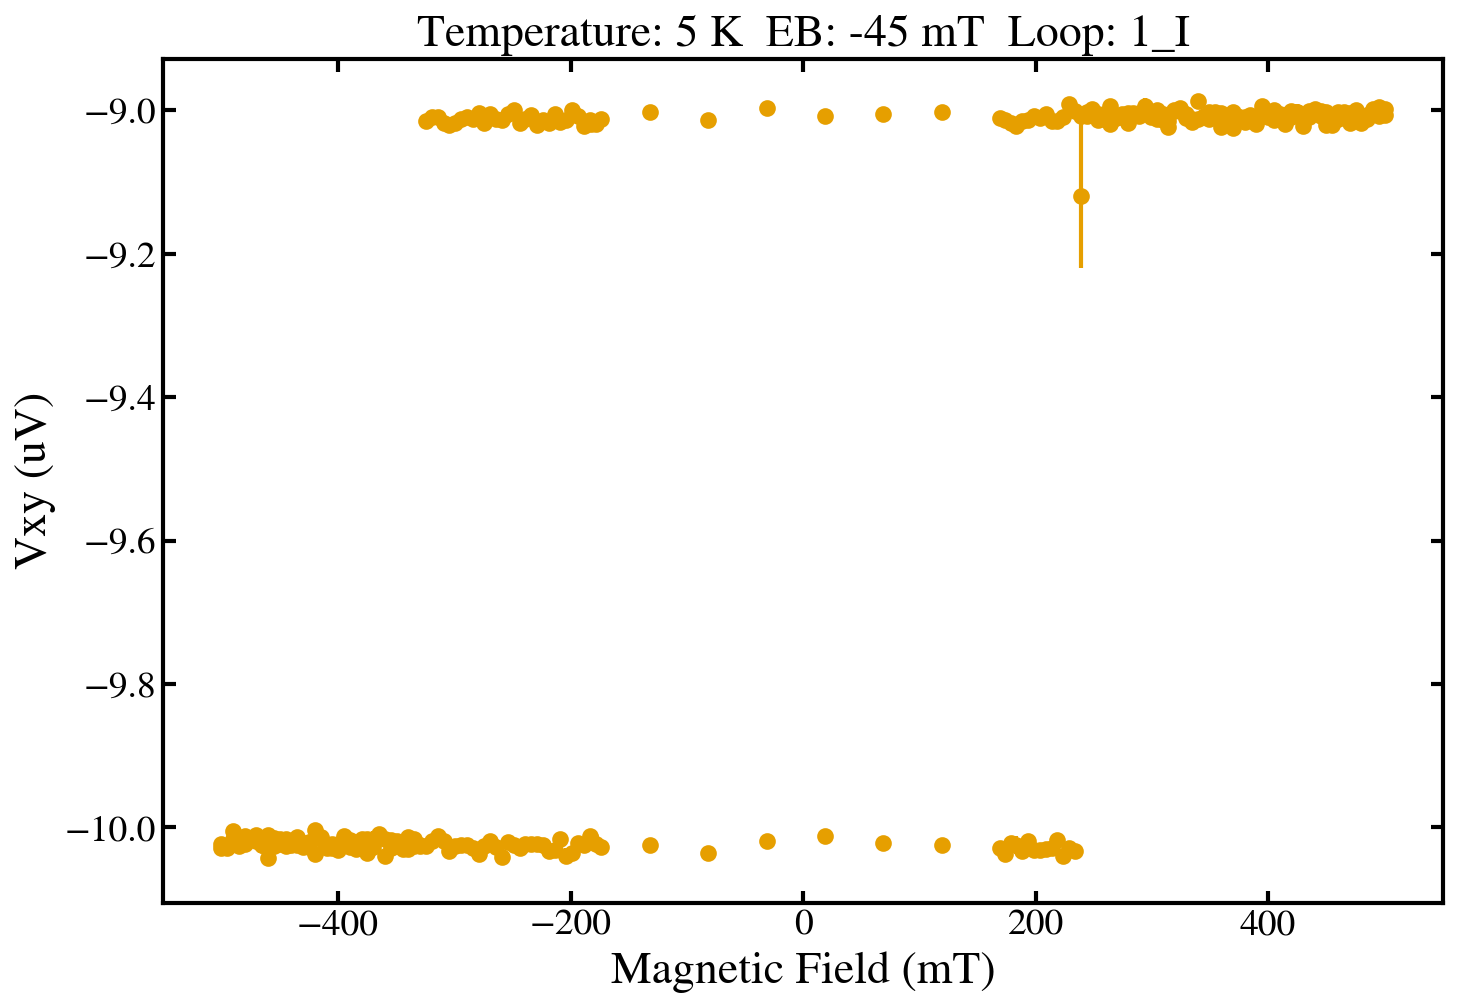

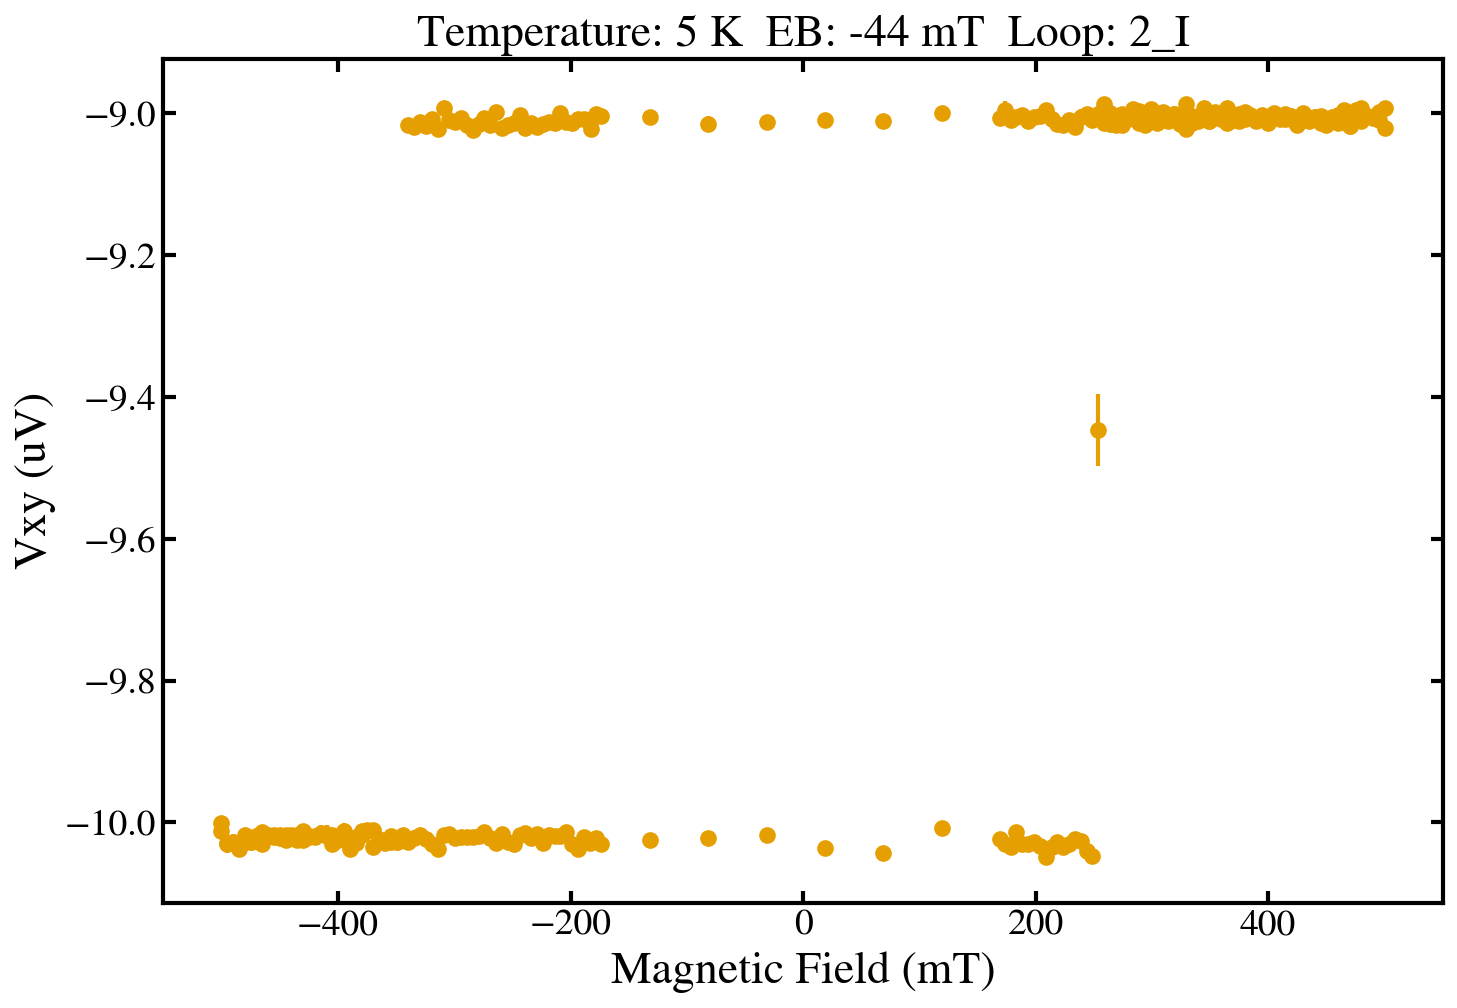

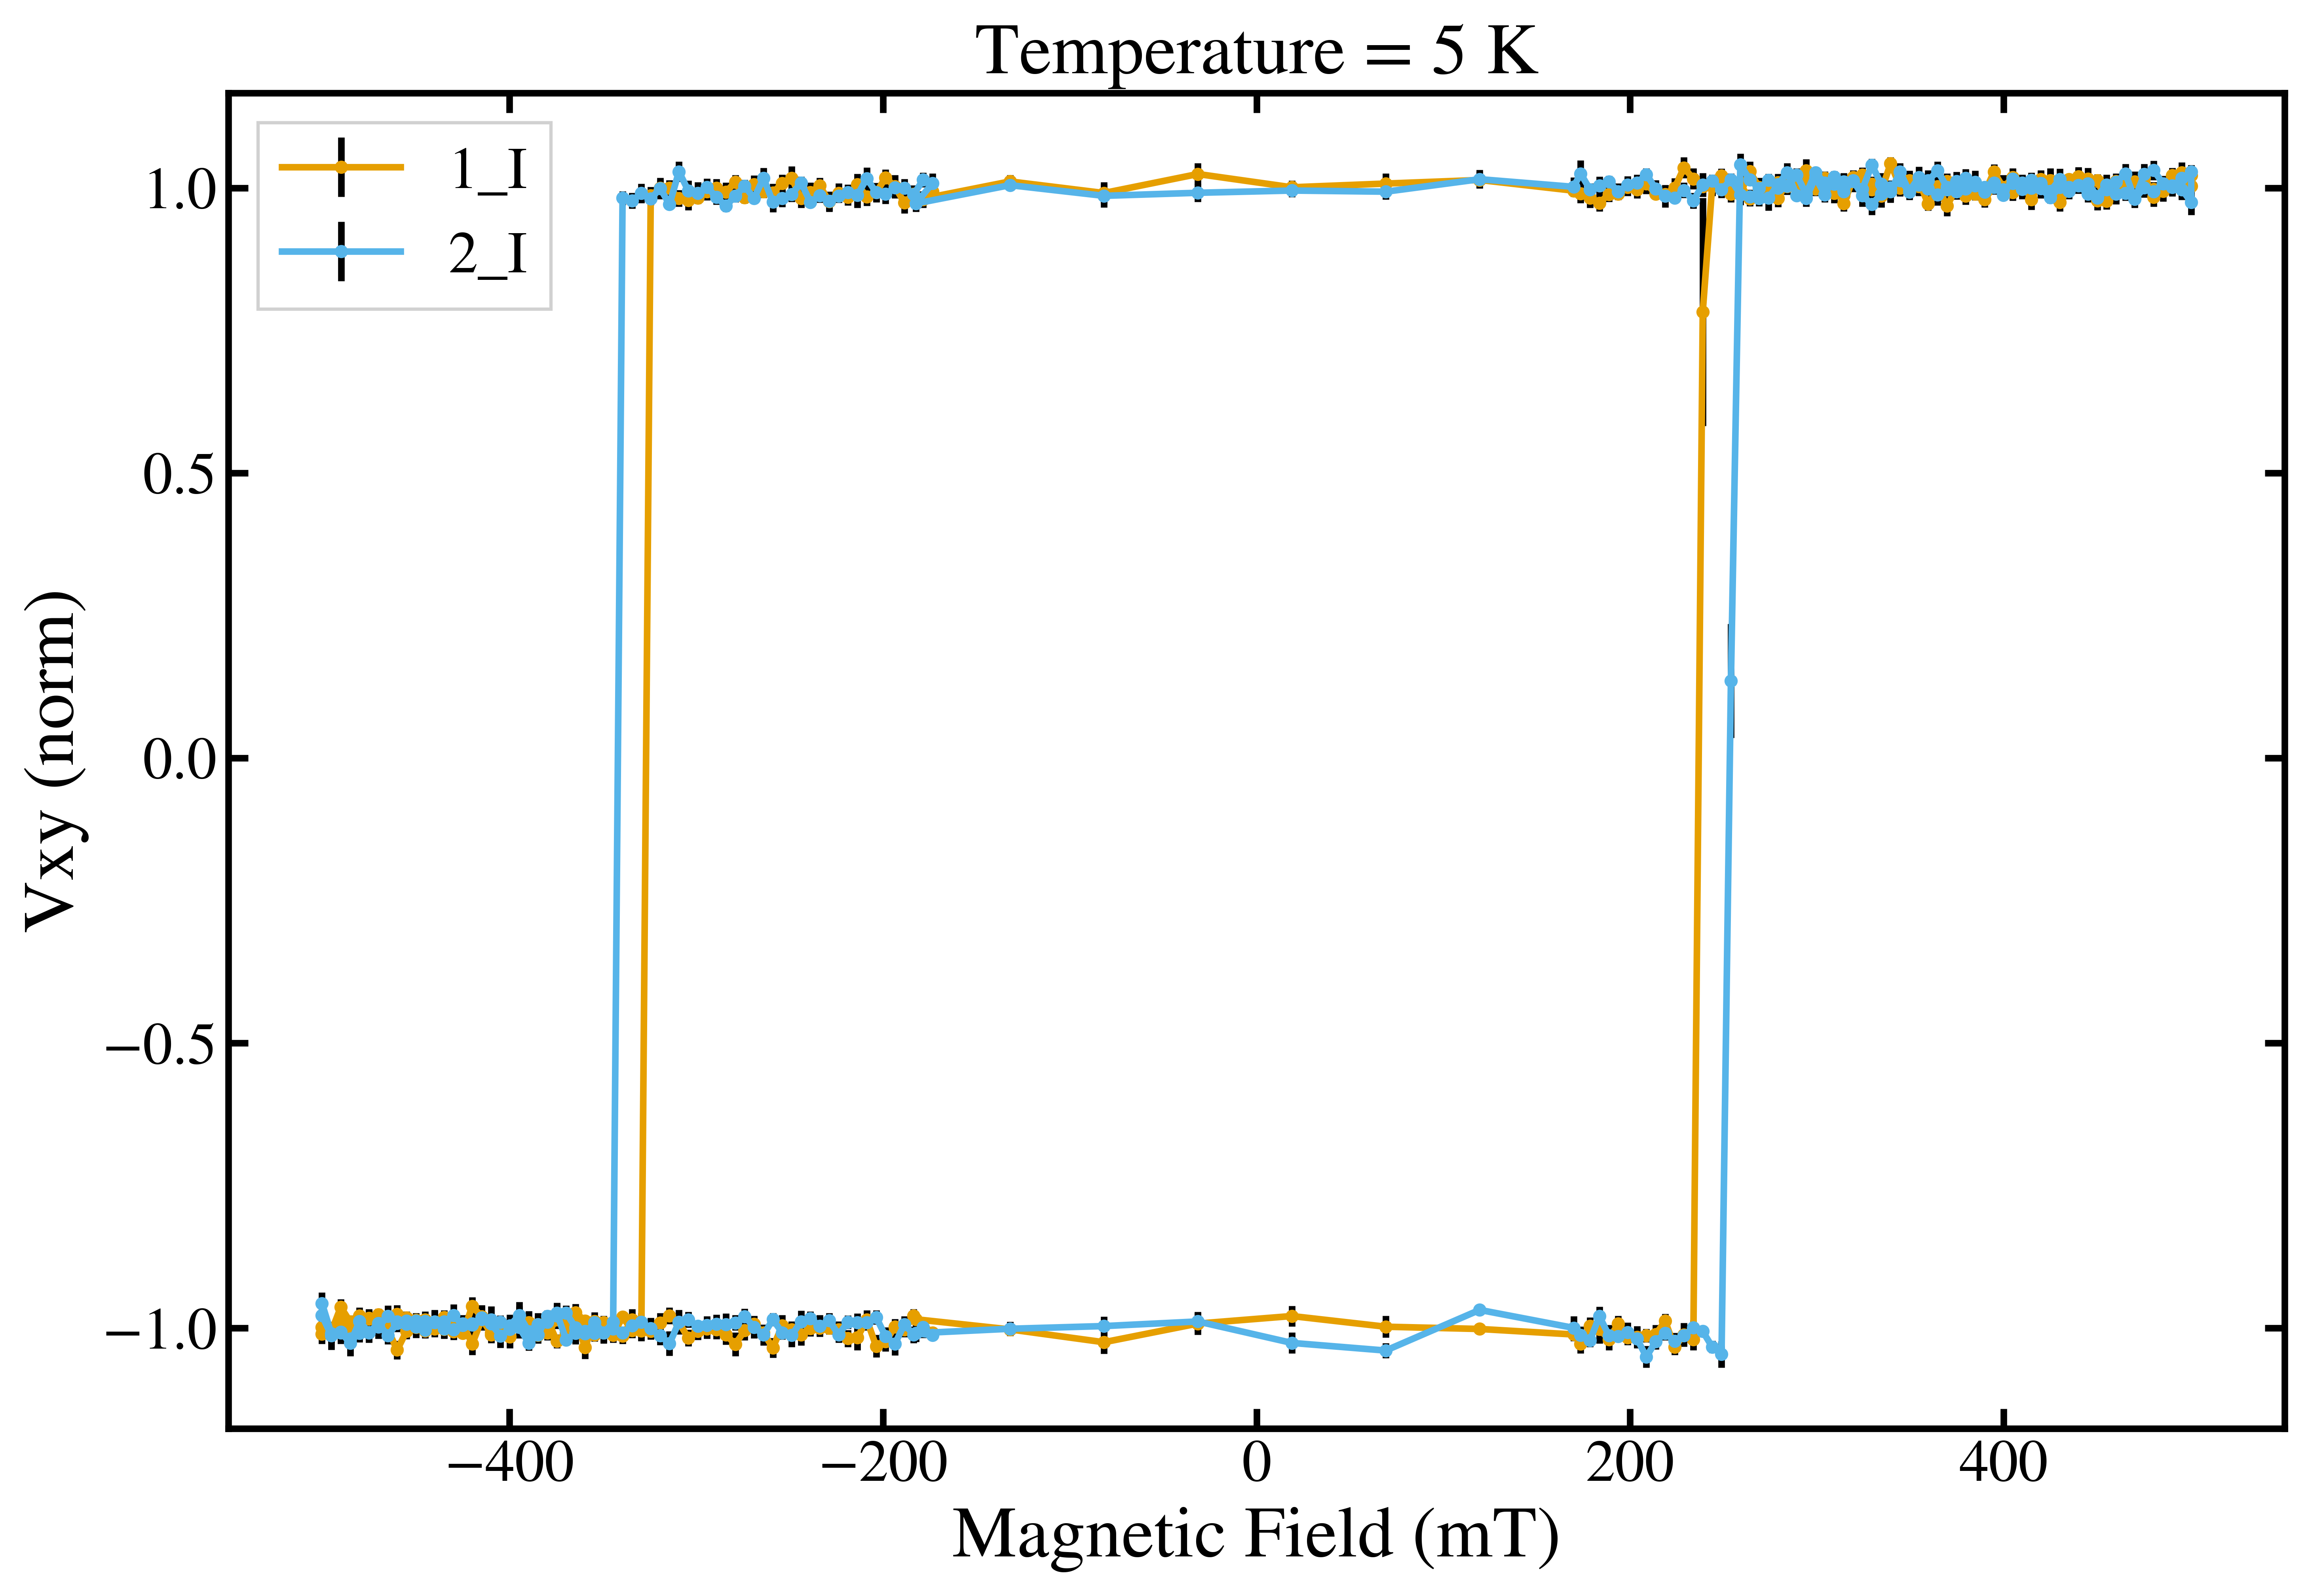

In [26]:
FOLDER_5K = TRAININGBASE / 'Training_effect_field_cooled' / 'Training_effect_5K' / 'Repeat'
res_5K = analyse_training_folder(FOLDER_5K)
if res_5K:
    summary_plots(res_5K, '5 K')

---
##  50K 

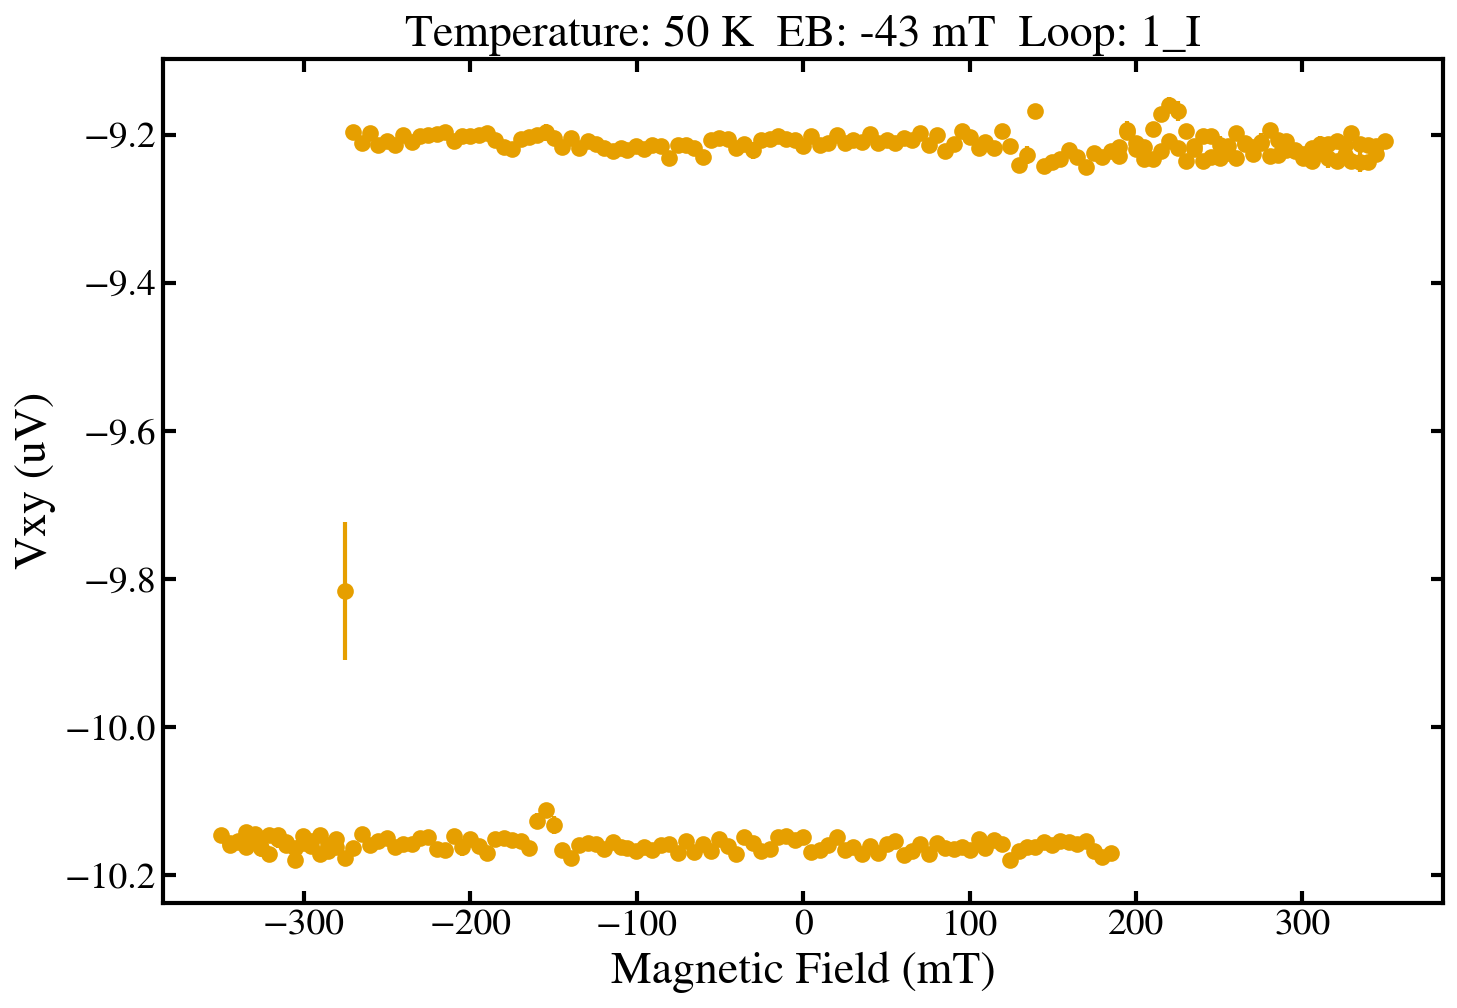

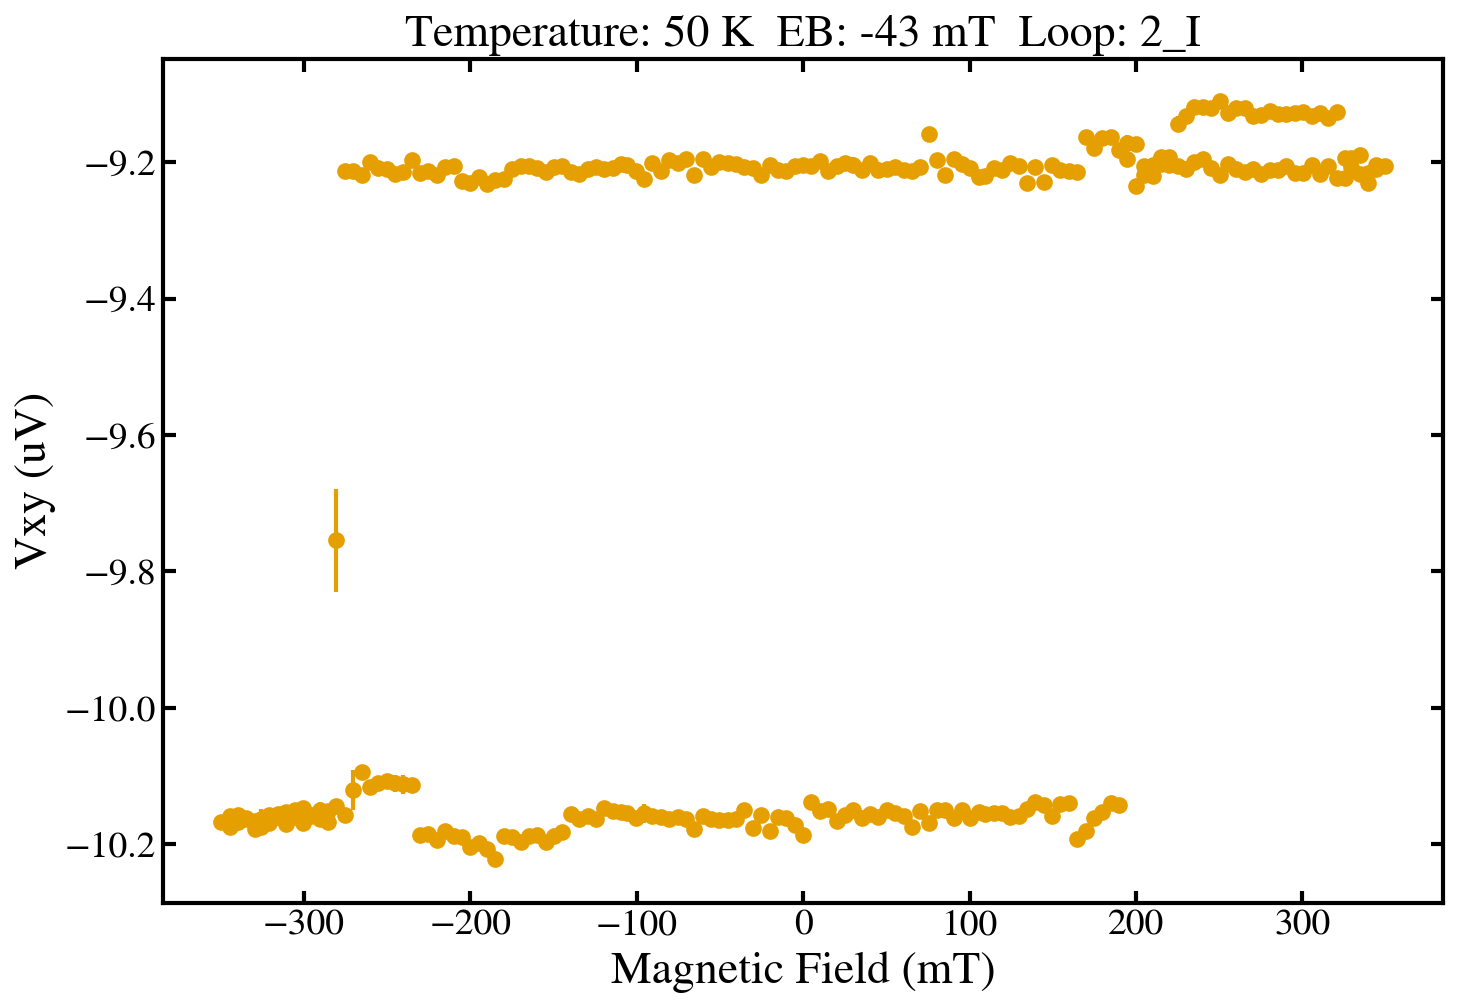

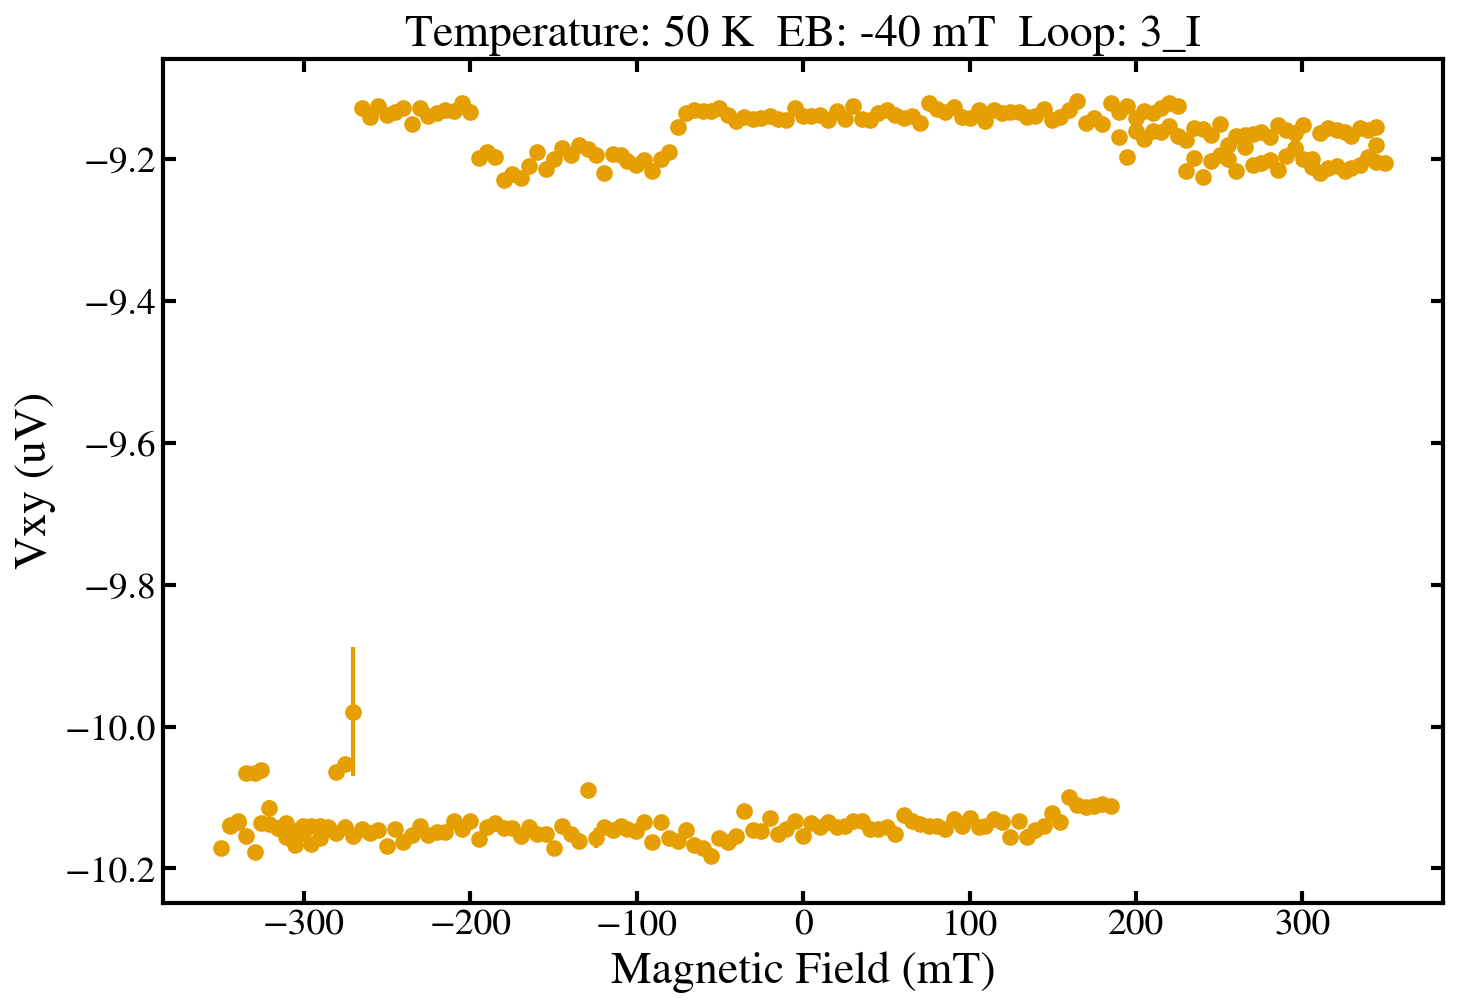

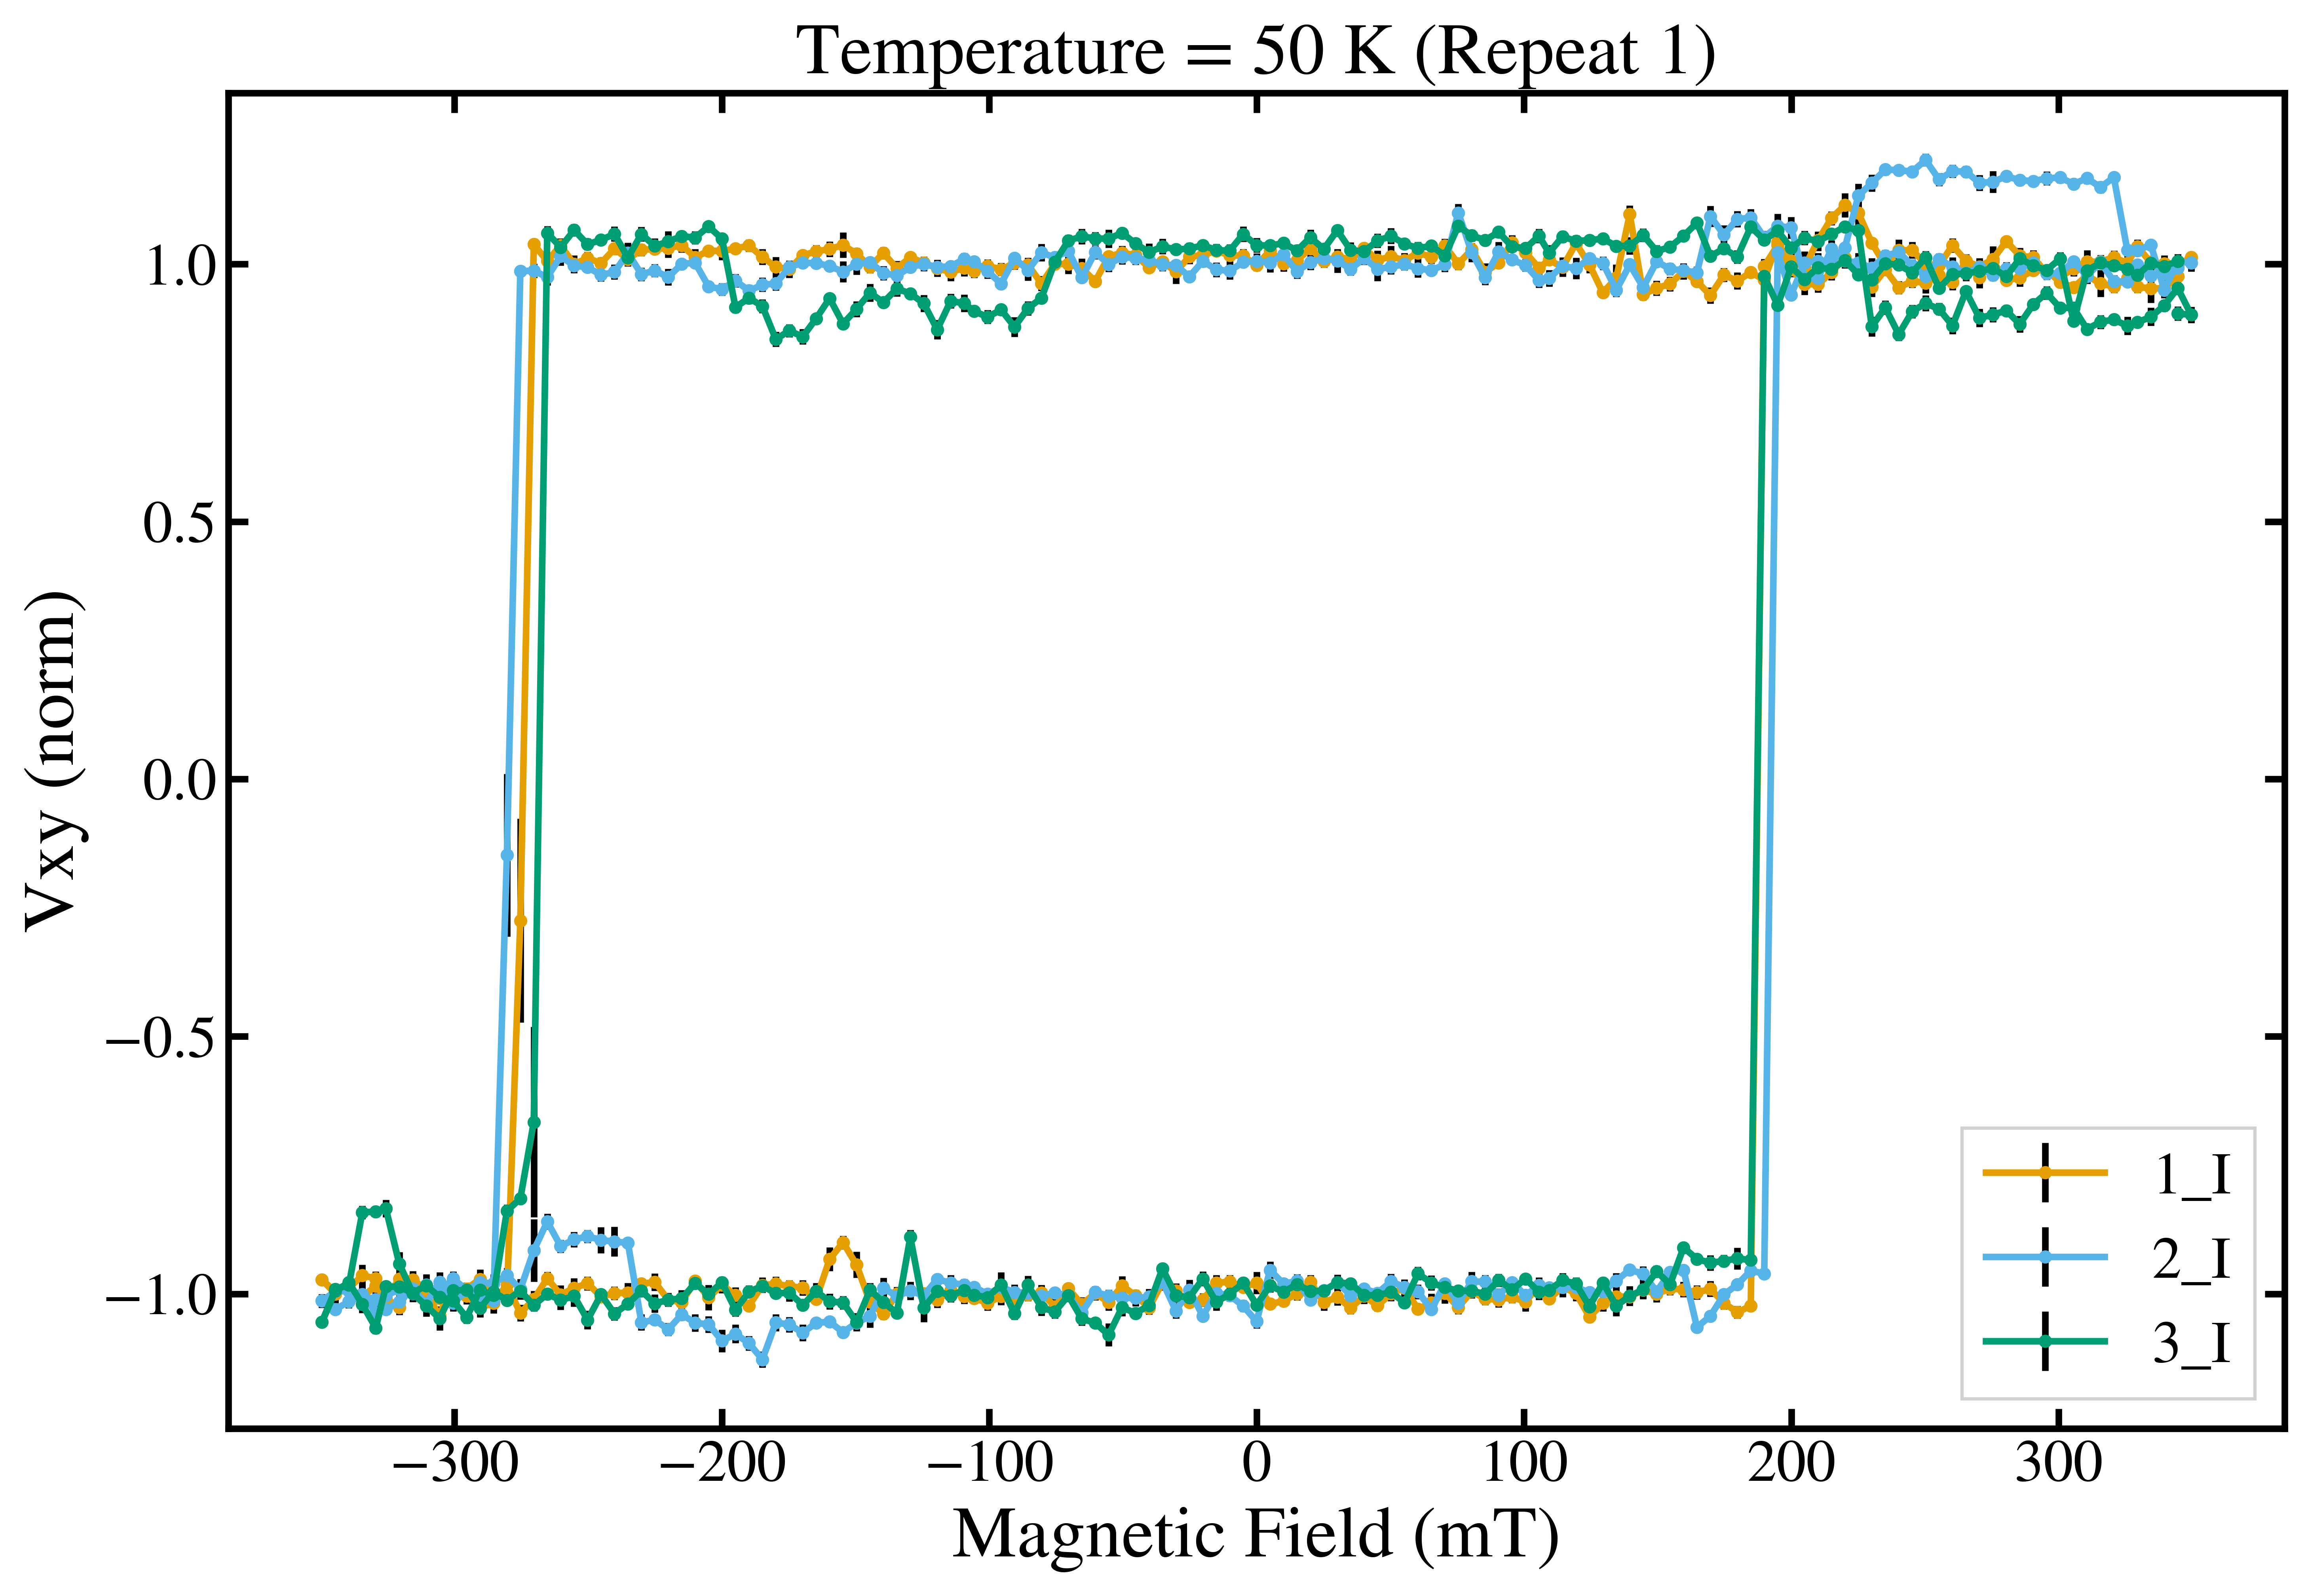

In [27]:
FOLDER_50K_R1 = TRAININGBASE / 'Training_effect_field_cooled' / 'Training_effct_50K' / 'Repeats' / 'Repeat_1'
res_50K_R1 = analyse_training_folder(FOLDER_50K_R1)
if res_50K_R1:
    summary_plots(res_50K_R1, '50 K (Repeat 1)')

---
## § 60K

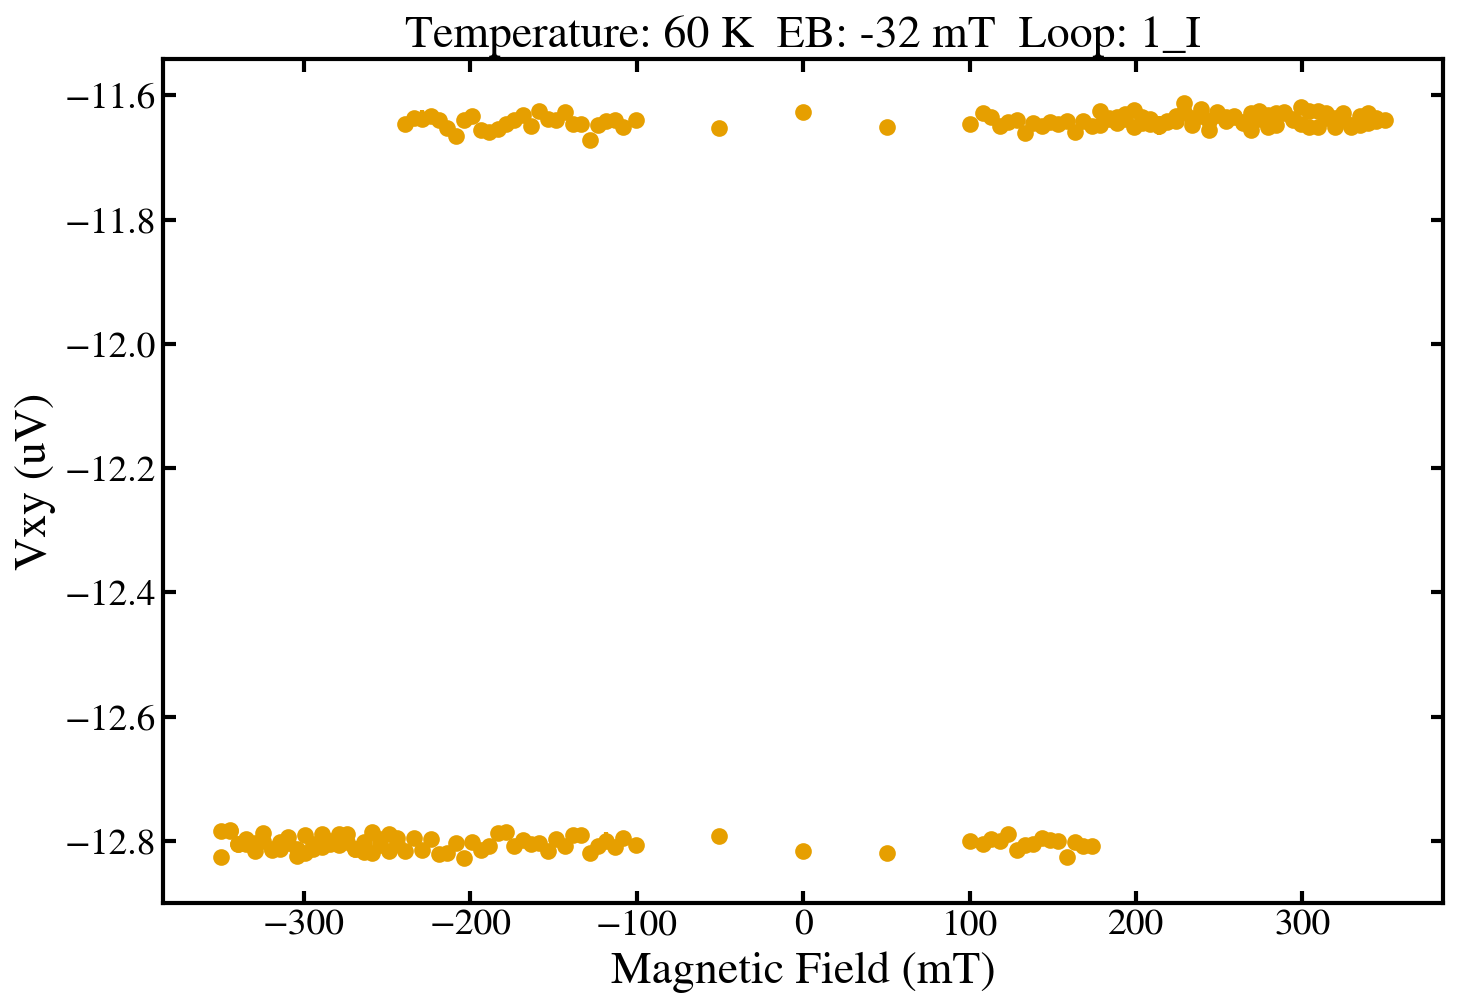

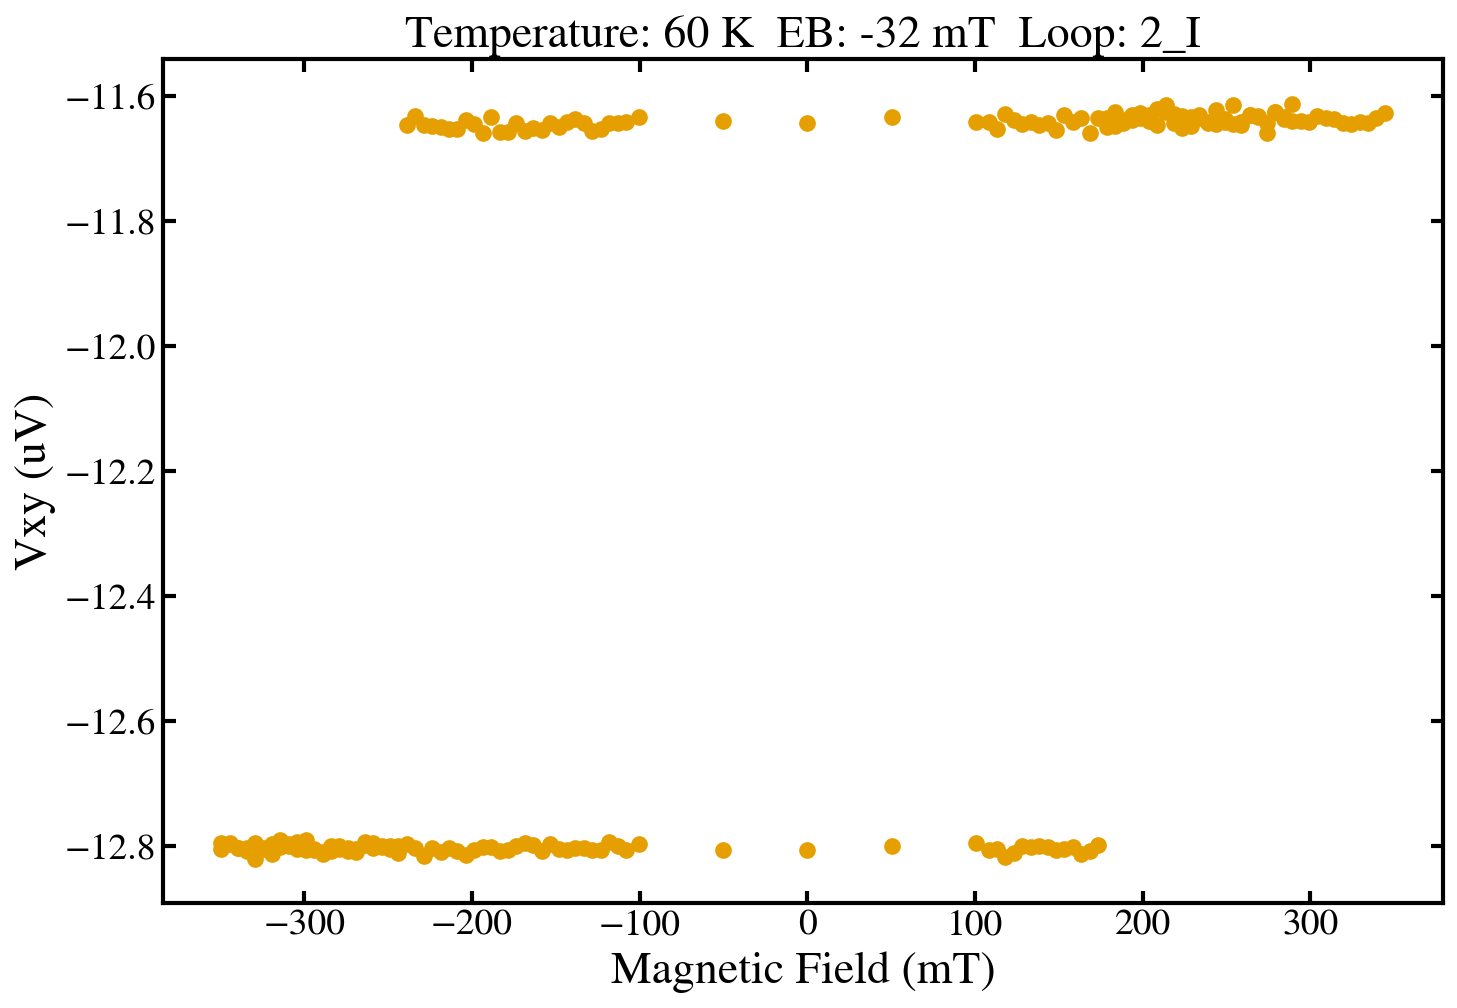

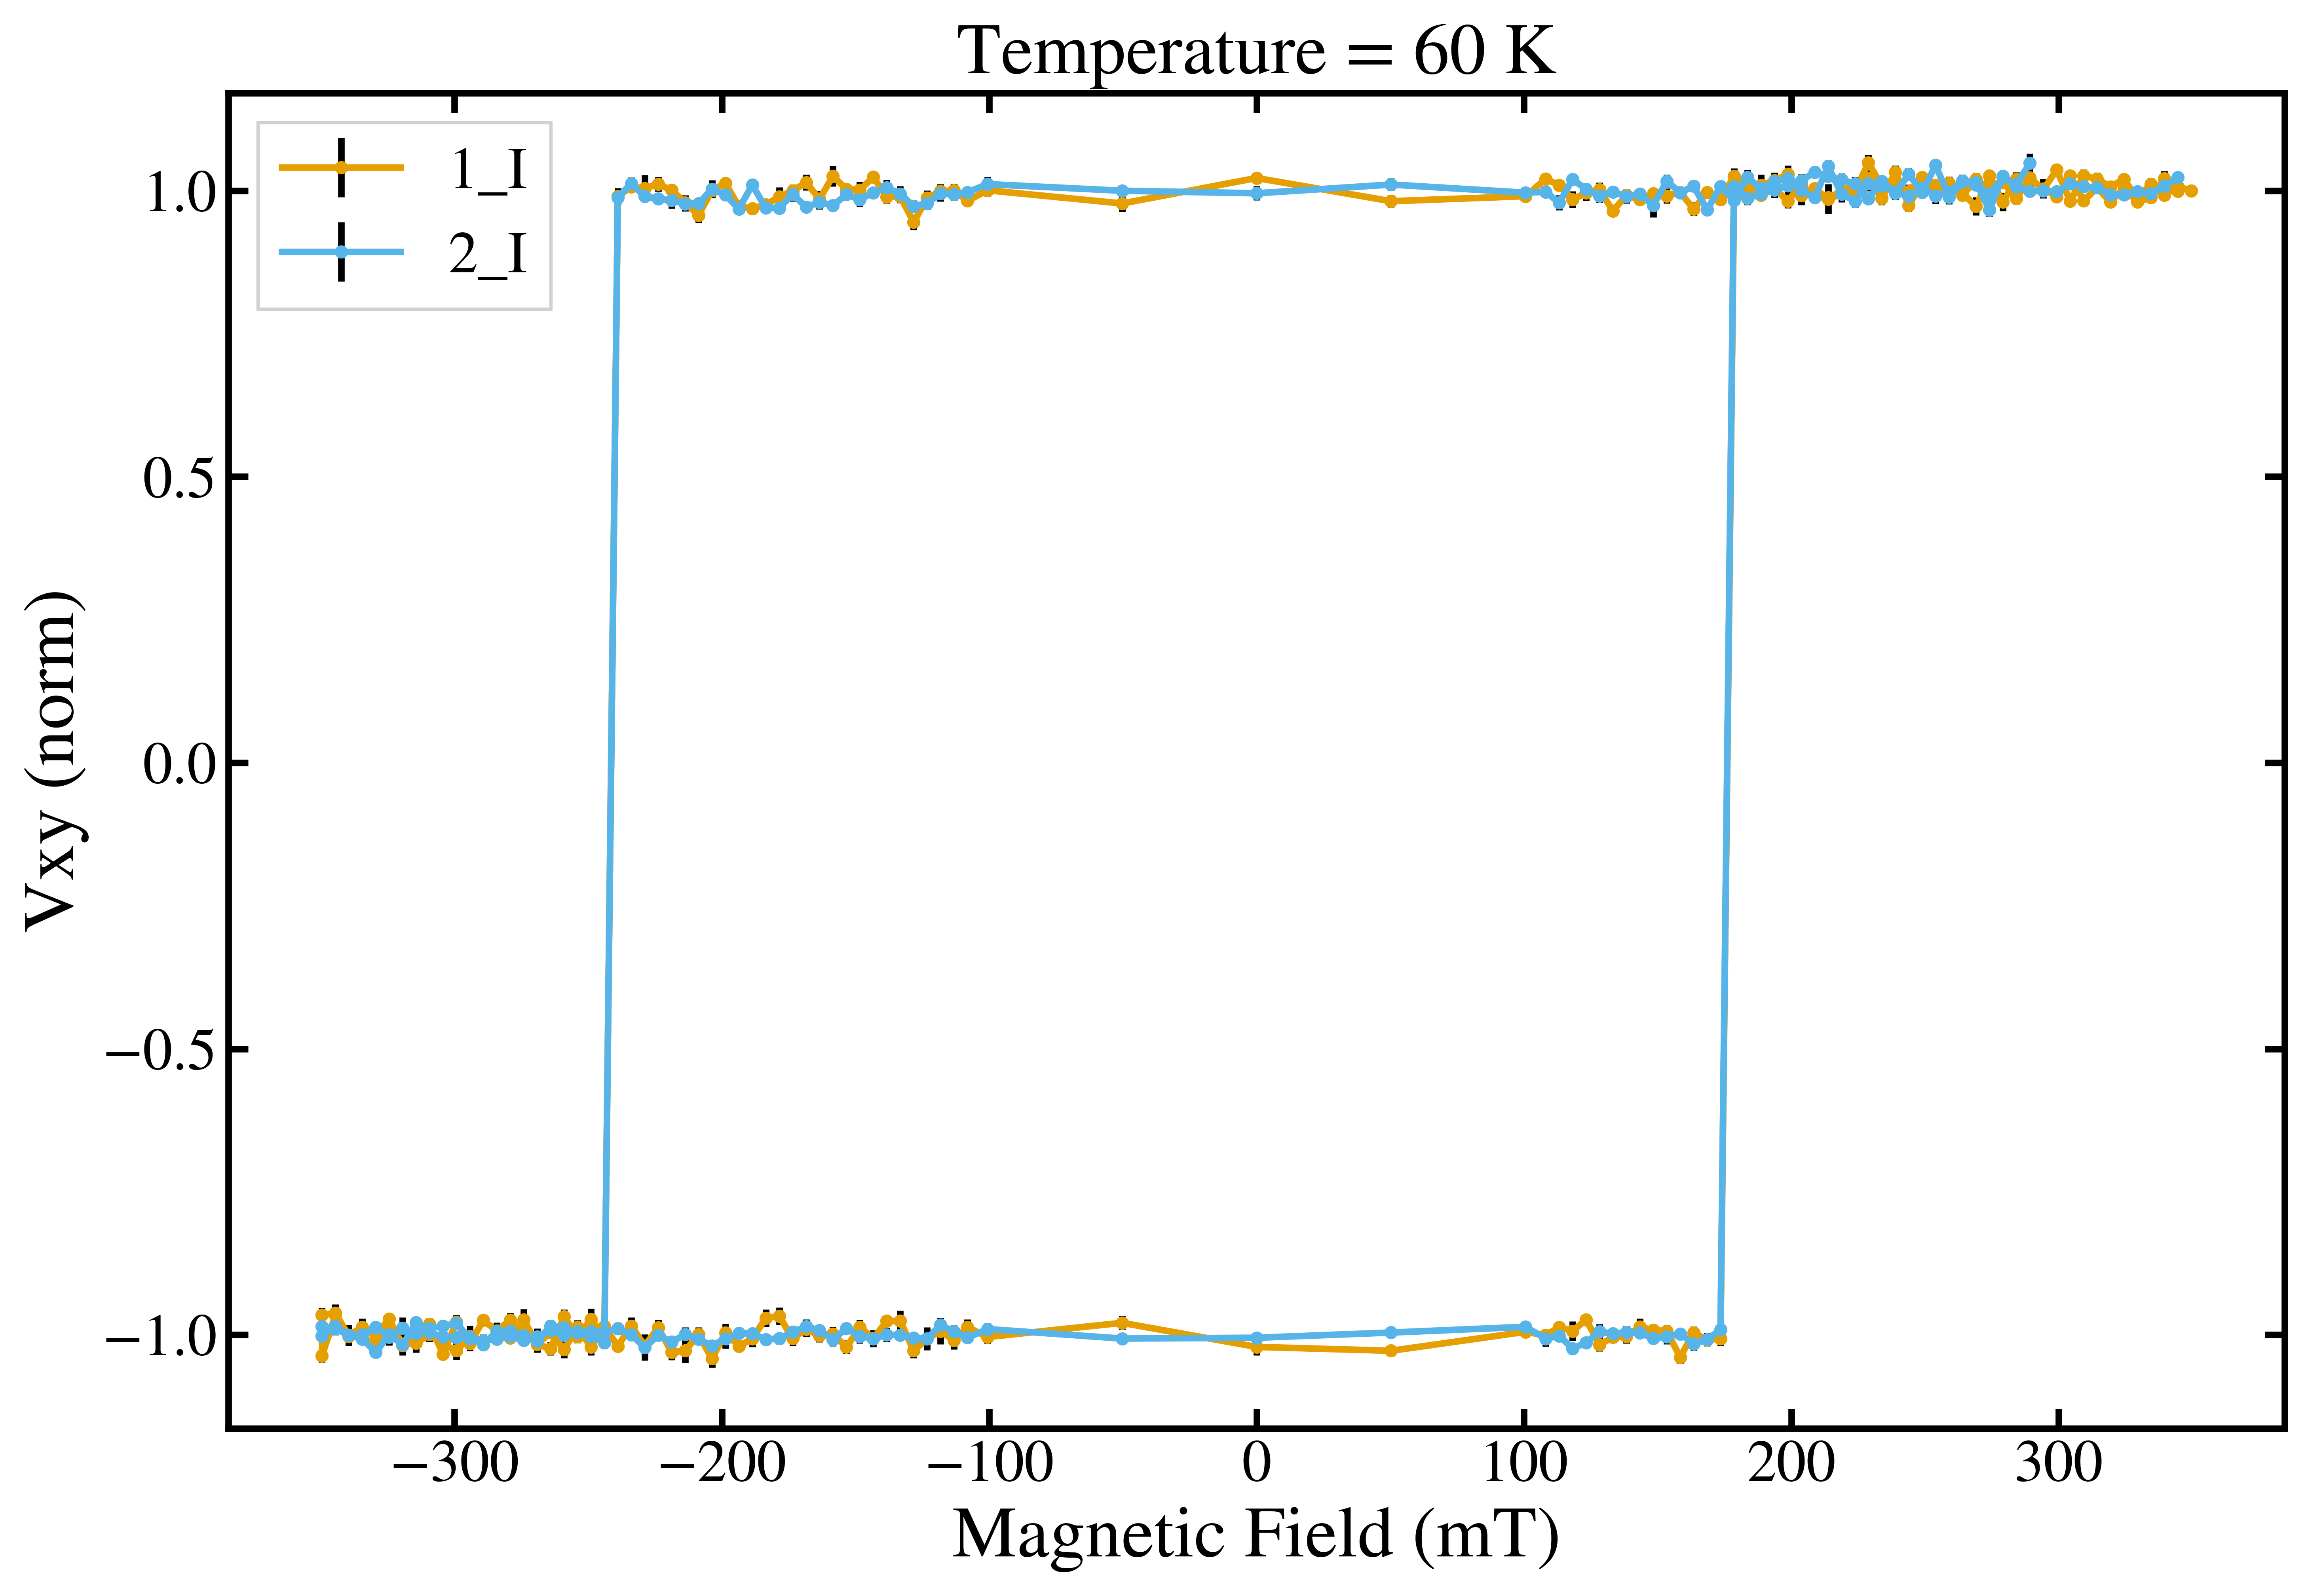

In [28]:
FOLDER_60K = TRAININGBASE / 'Training_effect_field_cooled' / 'Training_effect_60K'
res_60K = analyse_training_folder(FOLDER_60K)
if res_60K:
    summary_plots(res_60K, '60 K')

---
## § 80K

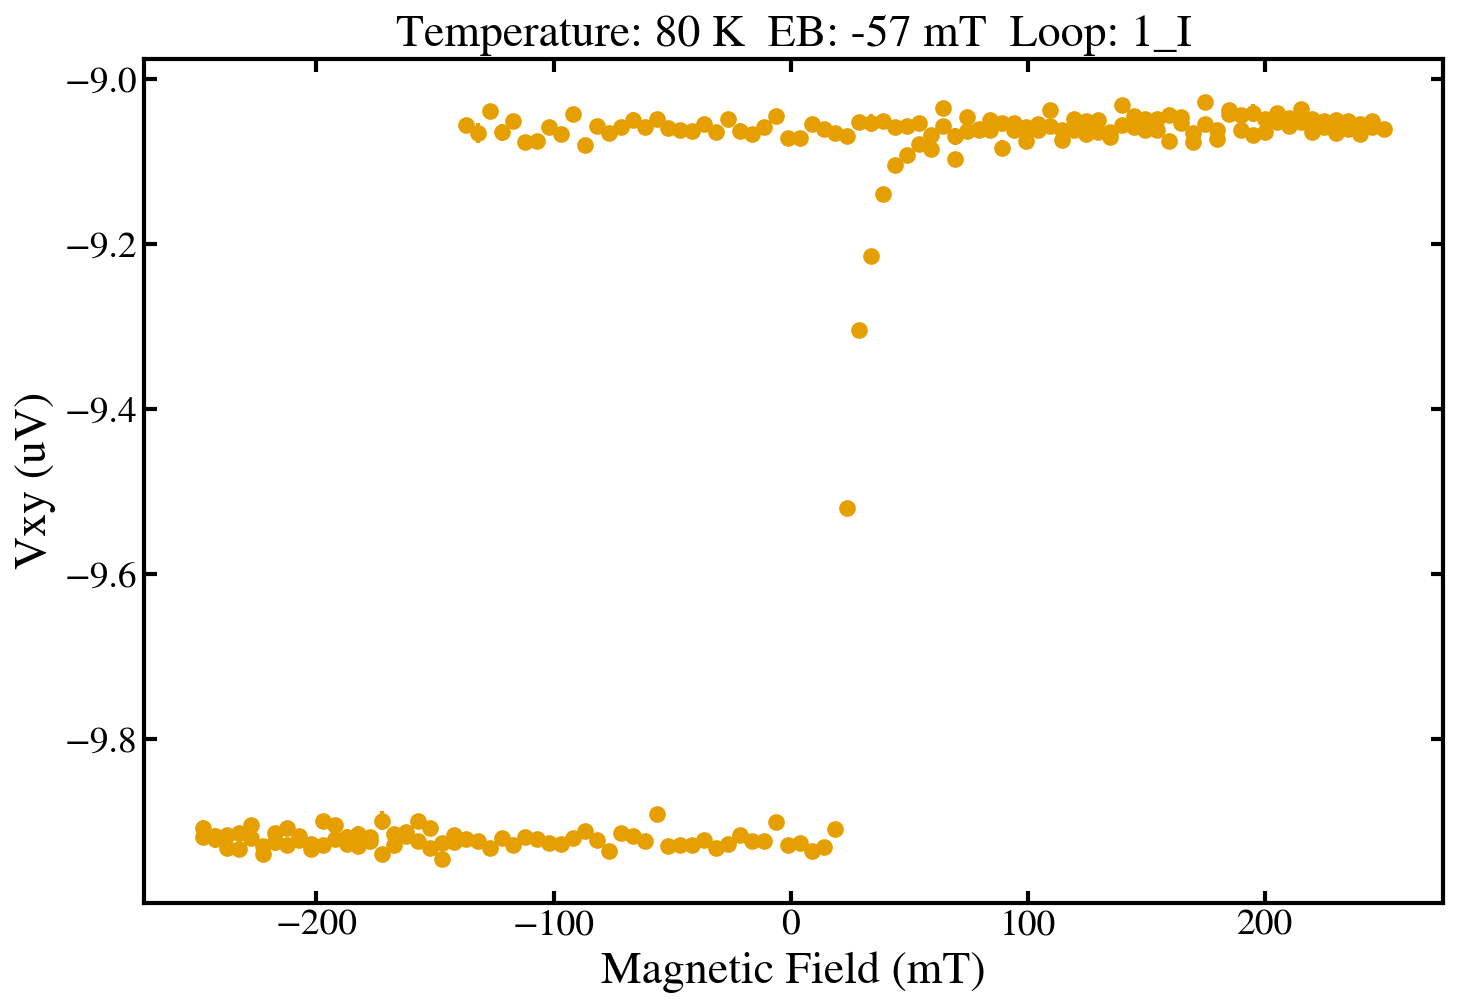

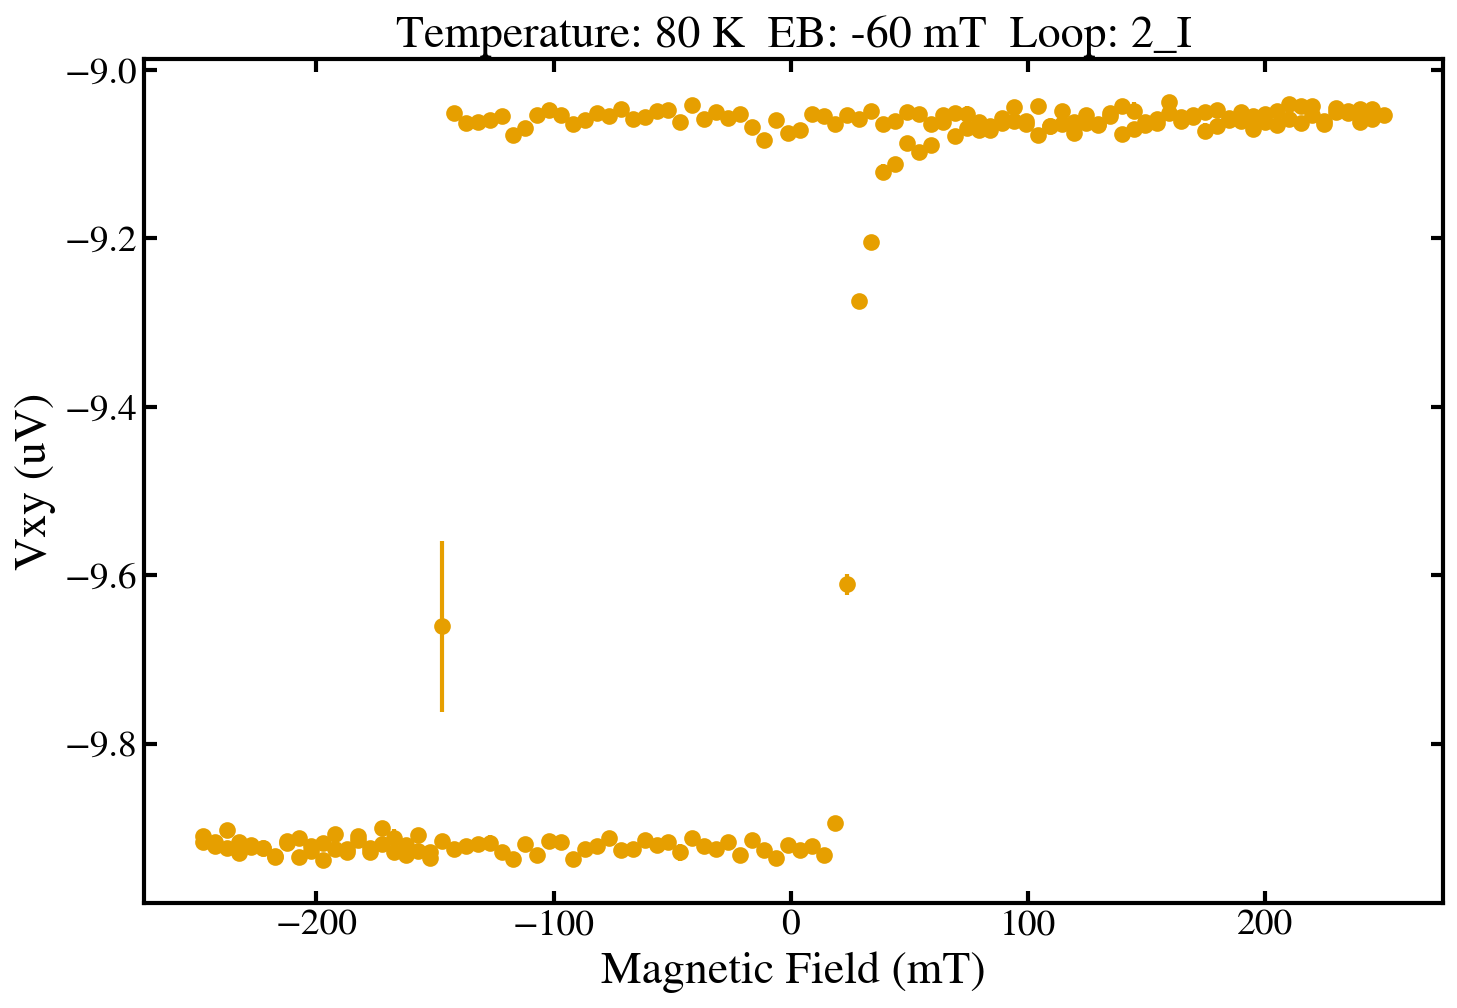

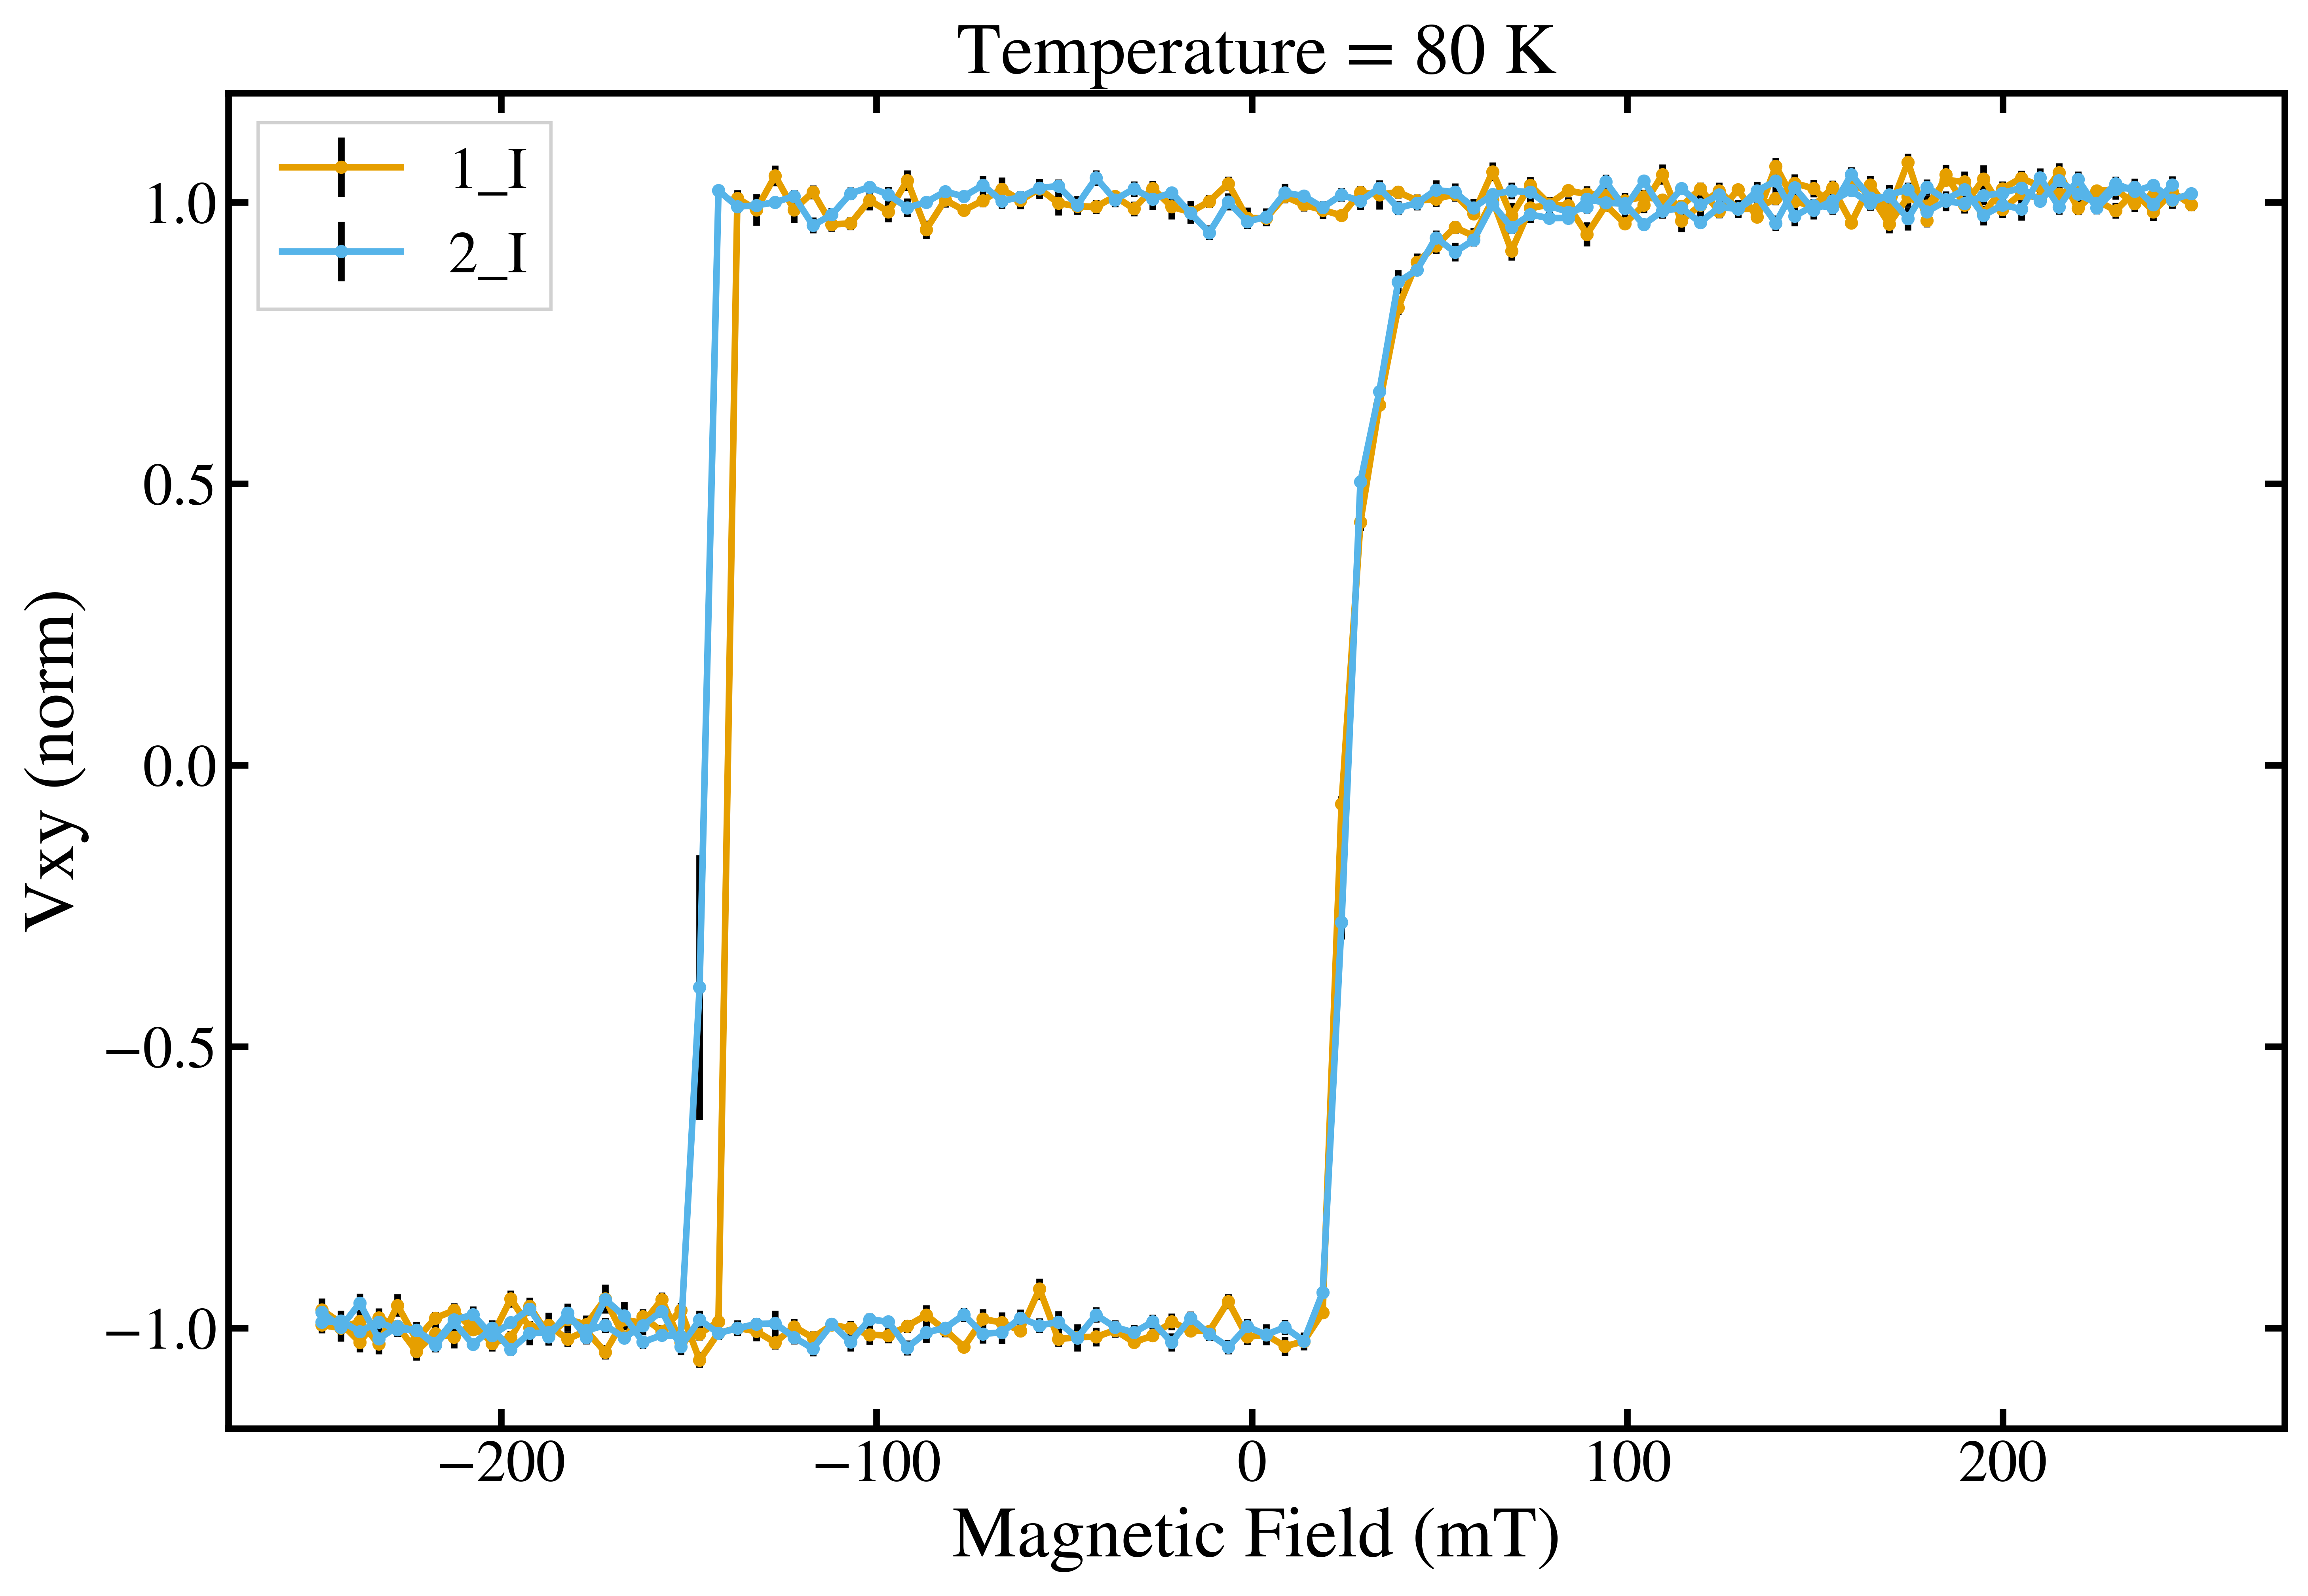

In [29]:
FOLDER_80K = TRAININGBASE / 'Training_effect_field_cooled' / 'Training_effect_80K'
res_80K = analyse_training_folder(FOLDER_80K)
if res_80K:
    summary_plots(res_80K, '80 K')

---
## § 100K

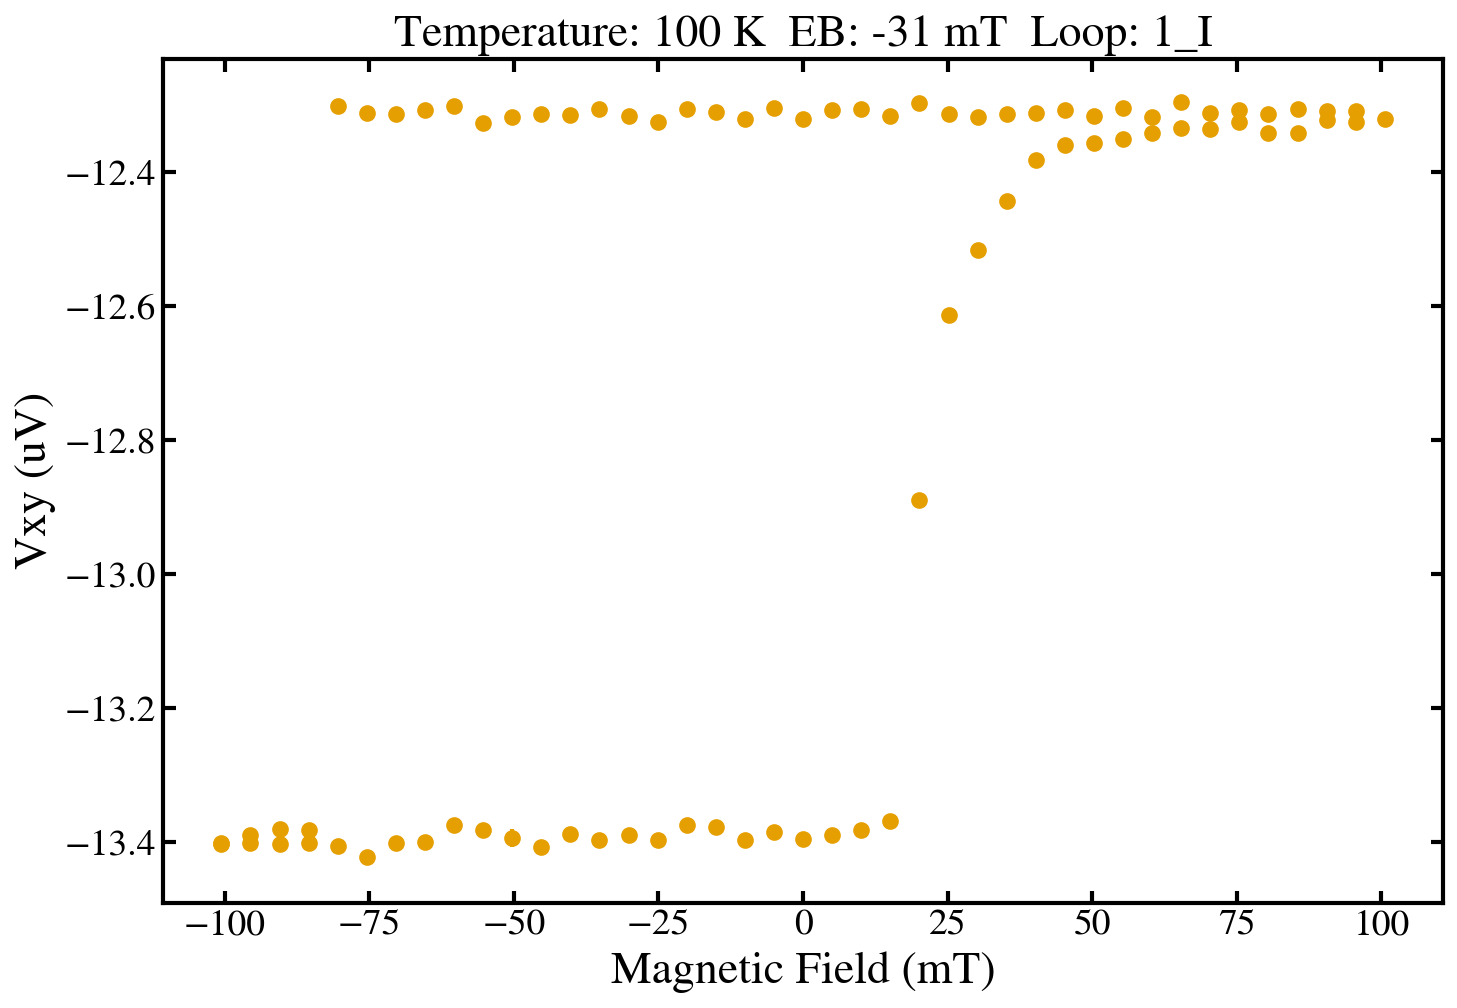

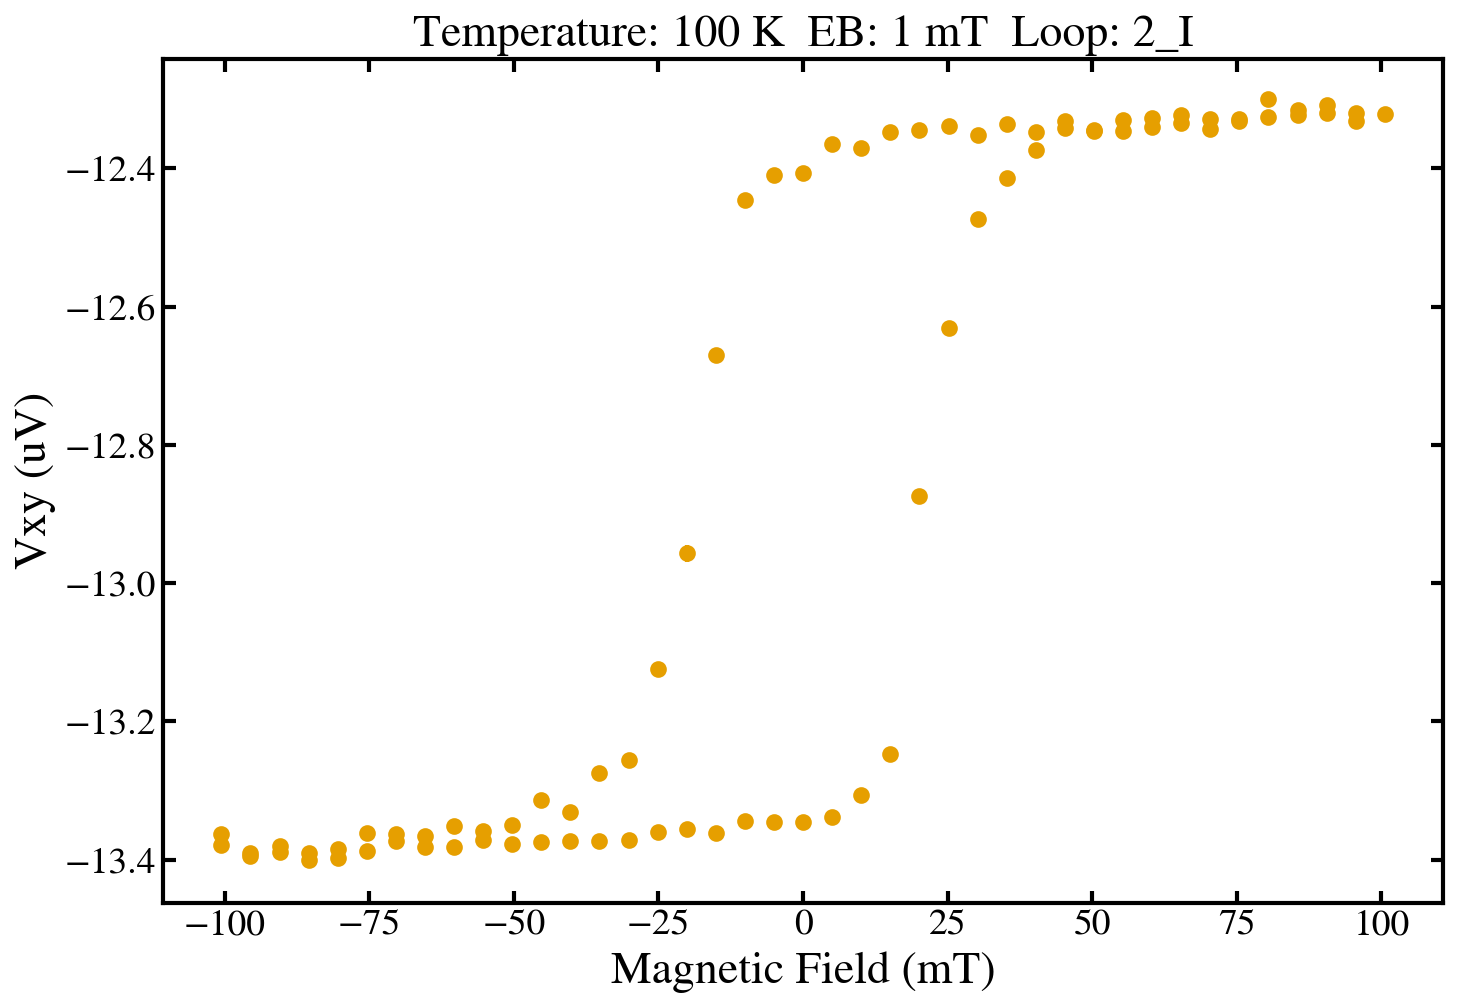

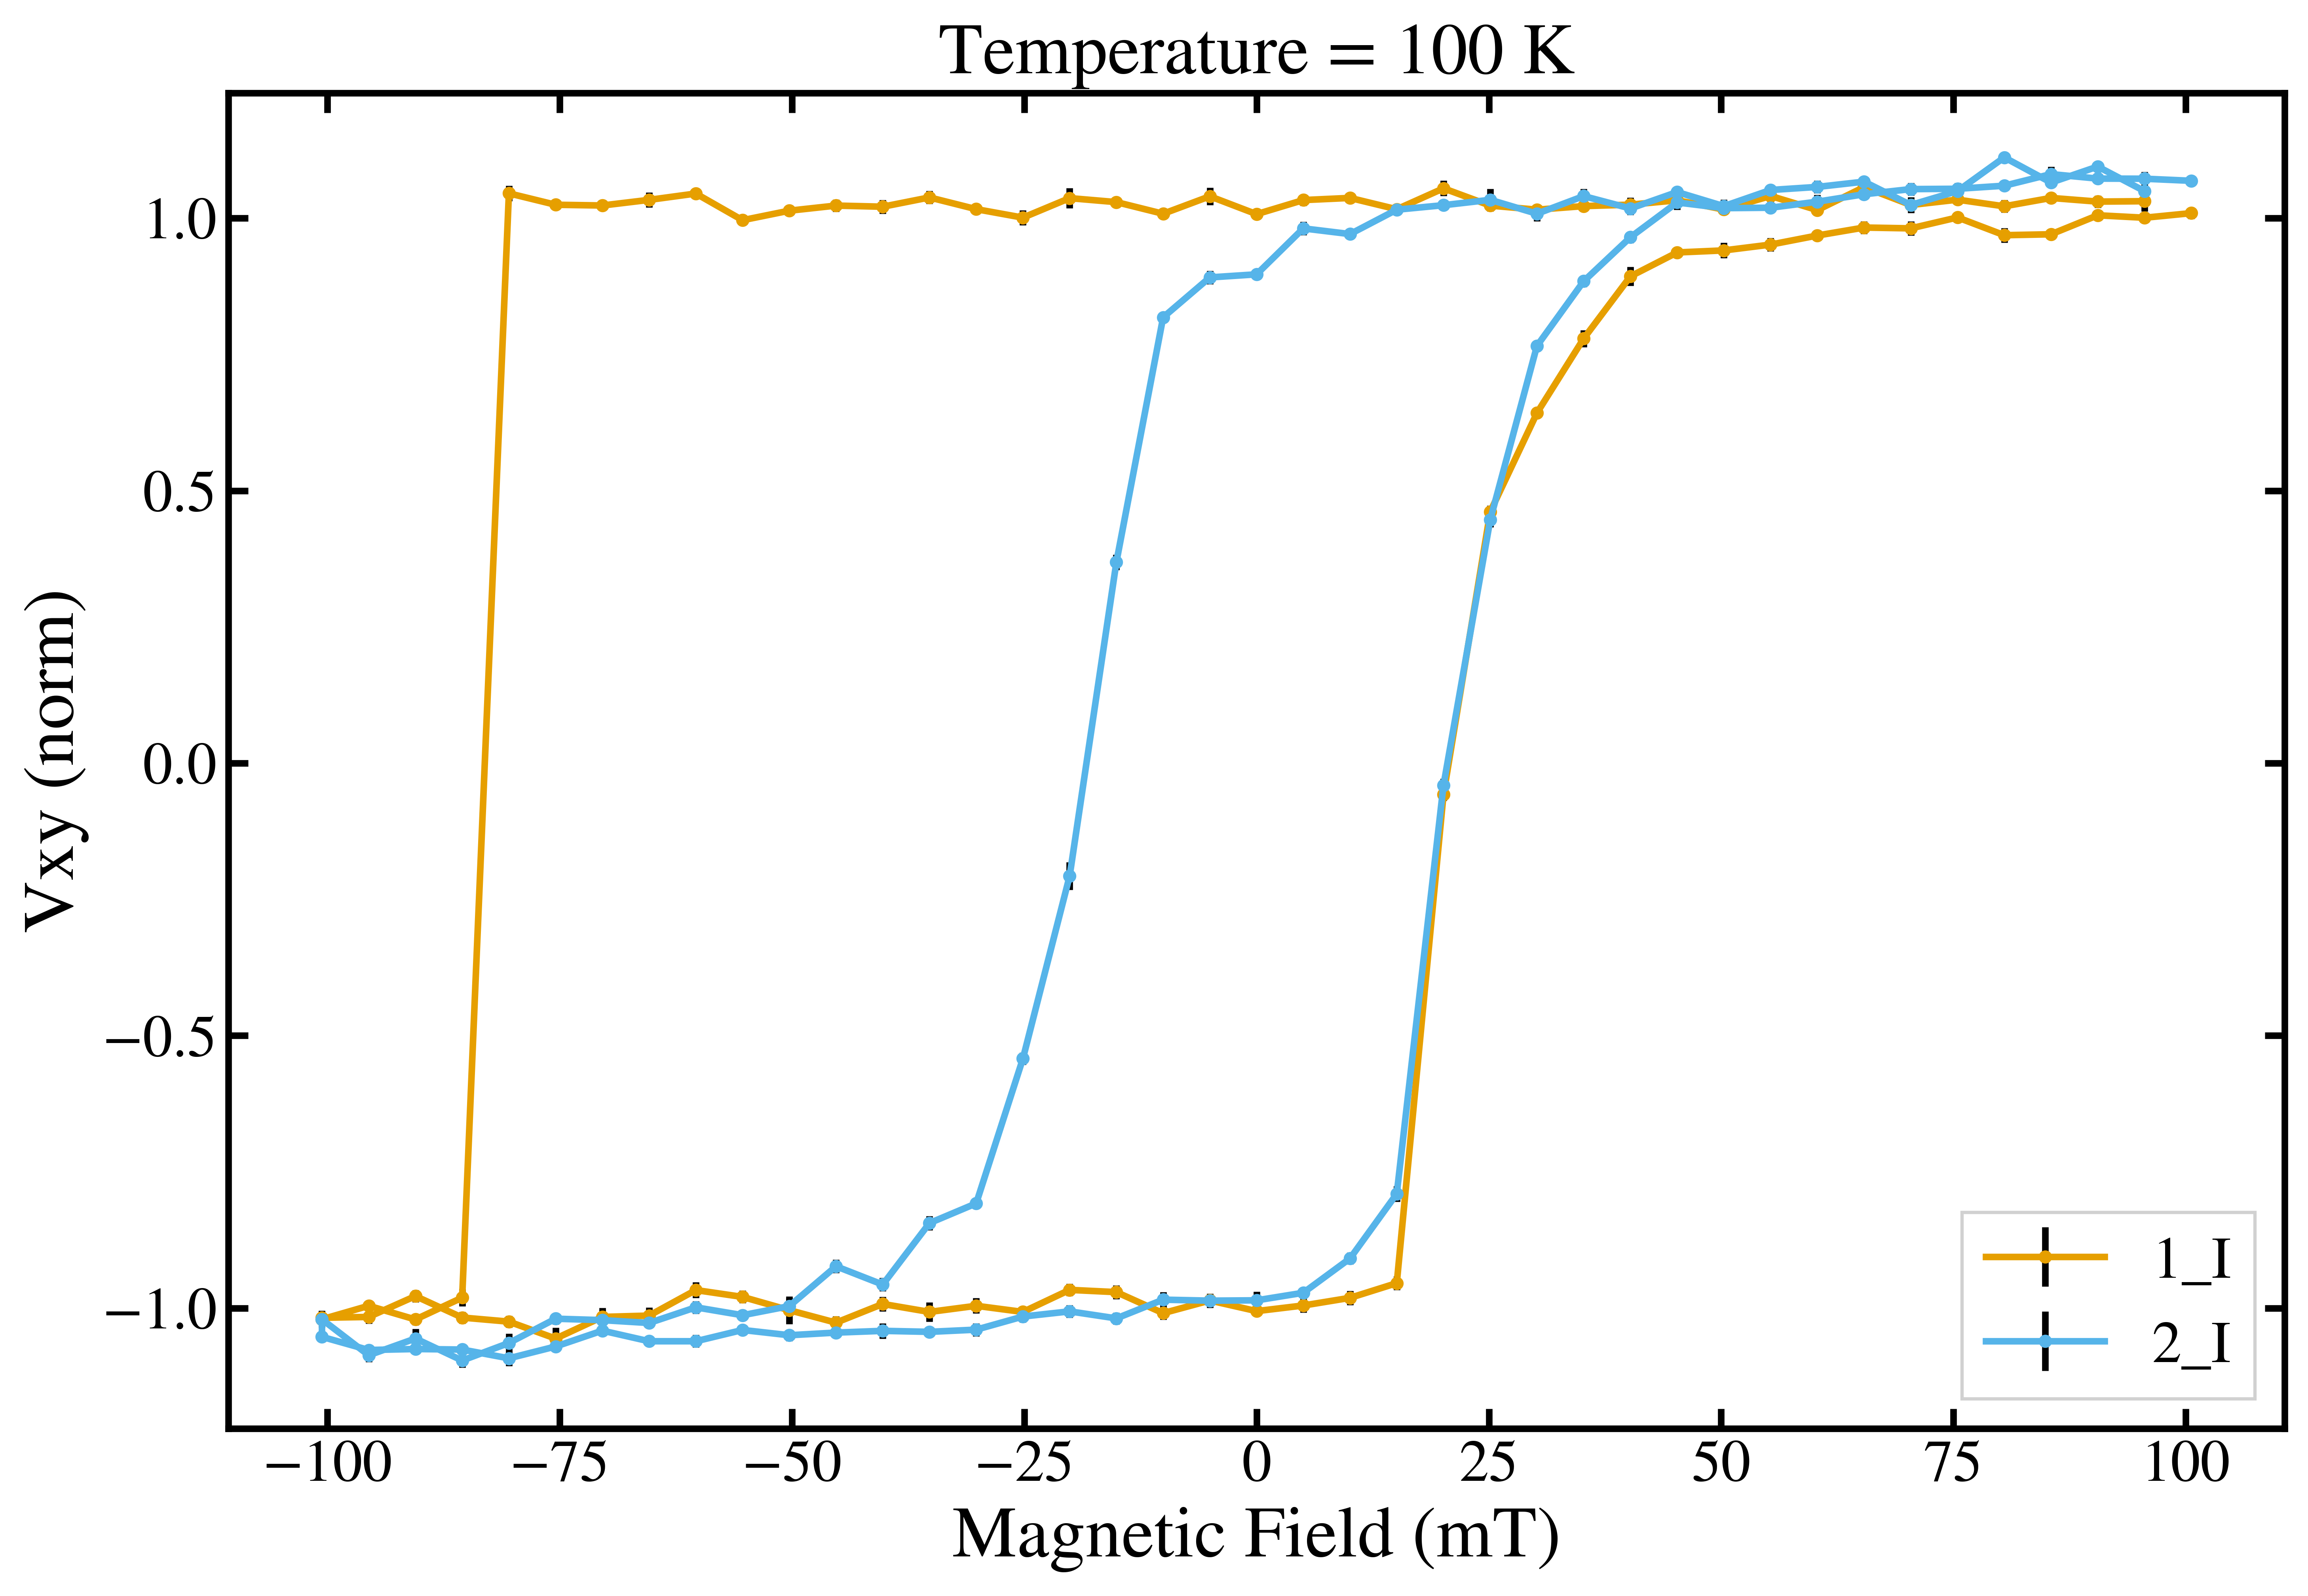

In [30]:
FOLDER_100K = TRAININGBASE / 'Training_effect_field_cooled' / 'Training_effect_100K'
res_100K = analyse_training_folder(FOLDER_100K)
if res_100K:
    summary_plots(res_100K, '100 K')

---
## § 120K

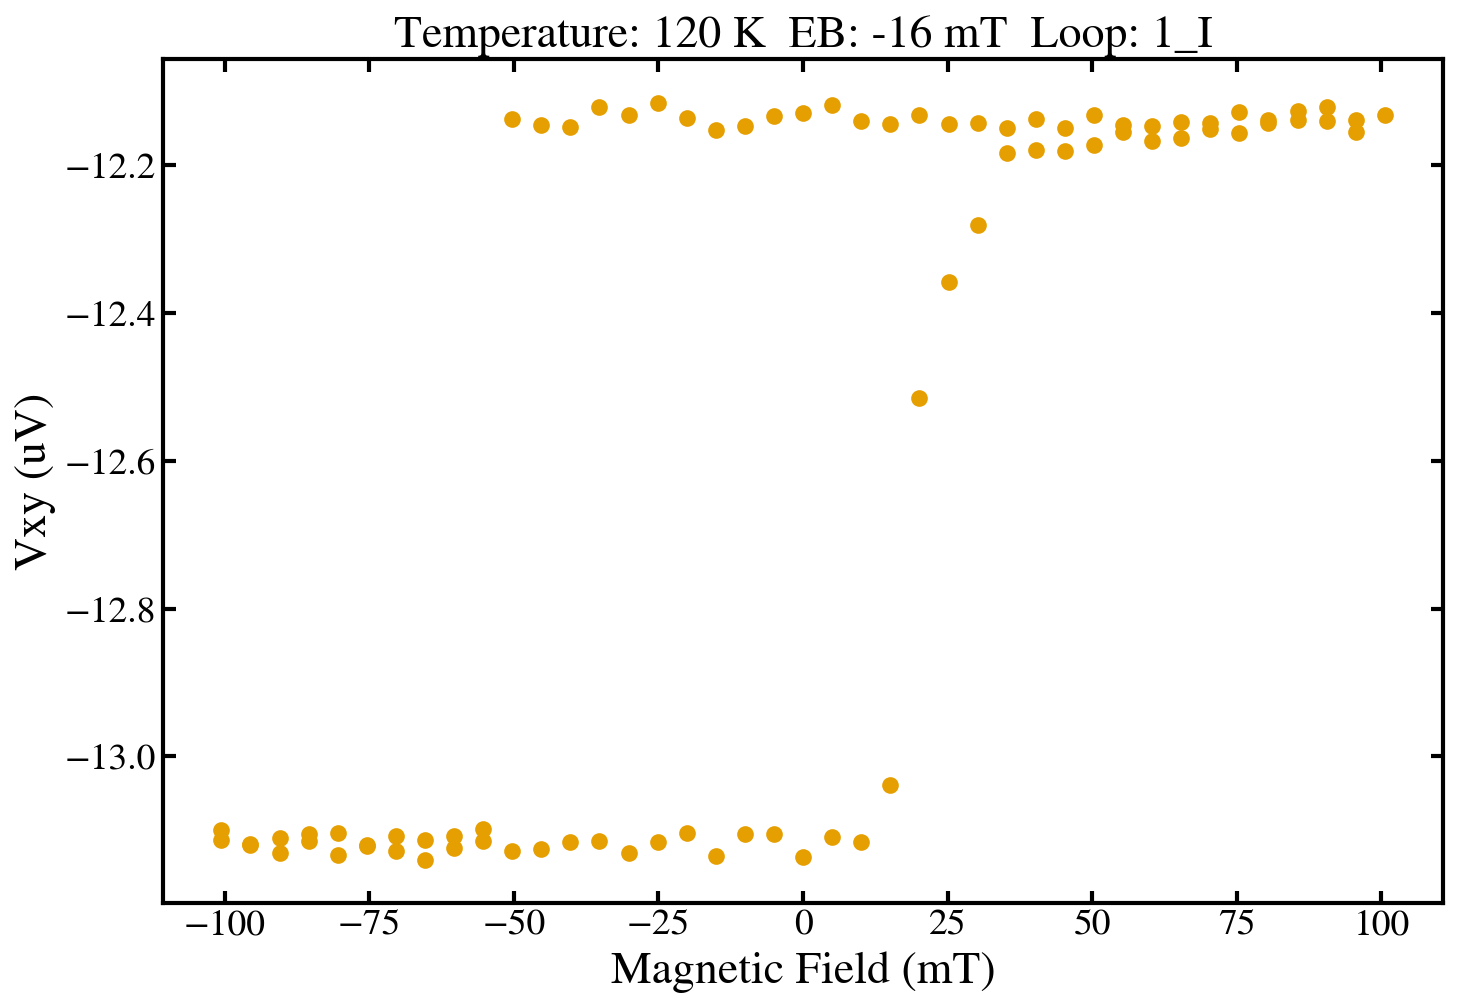

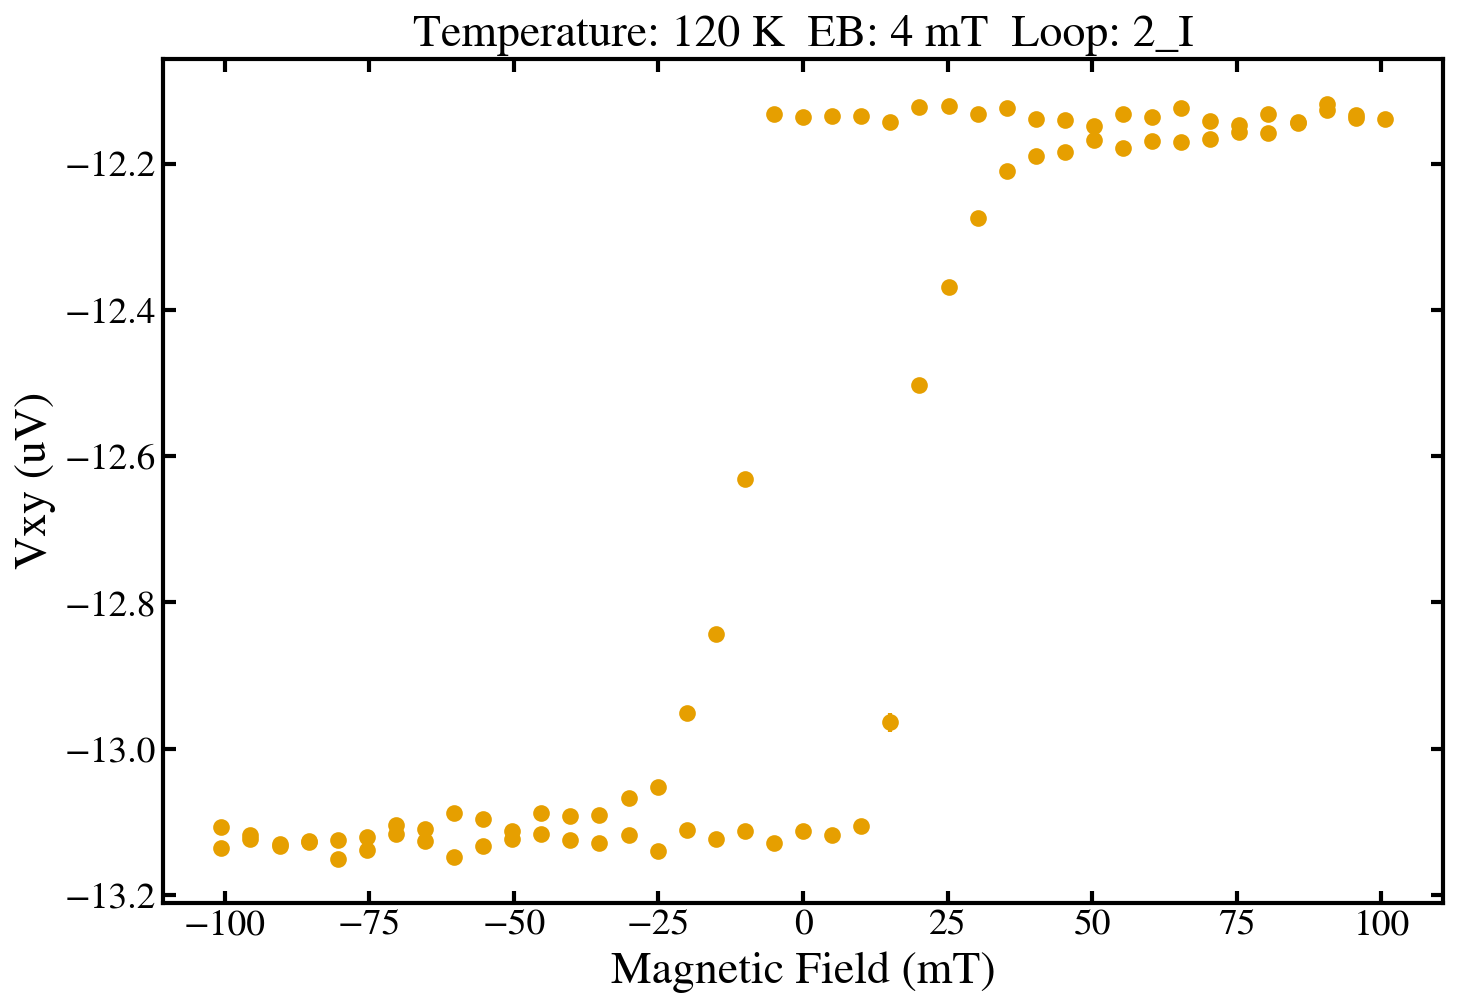

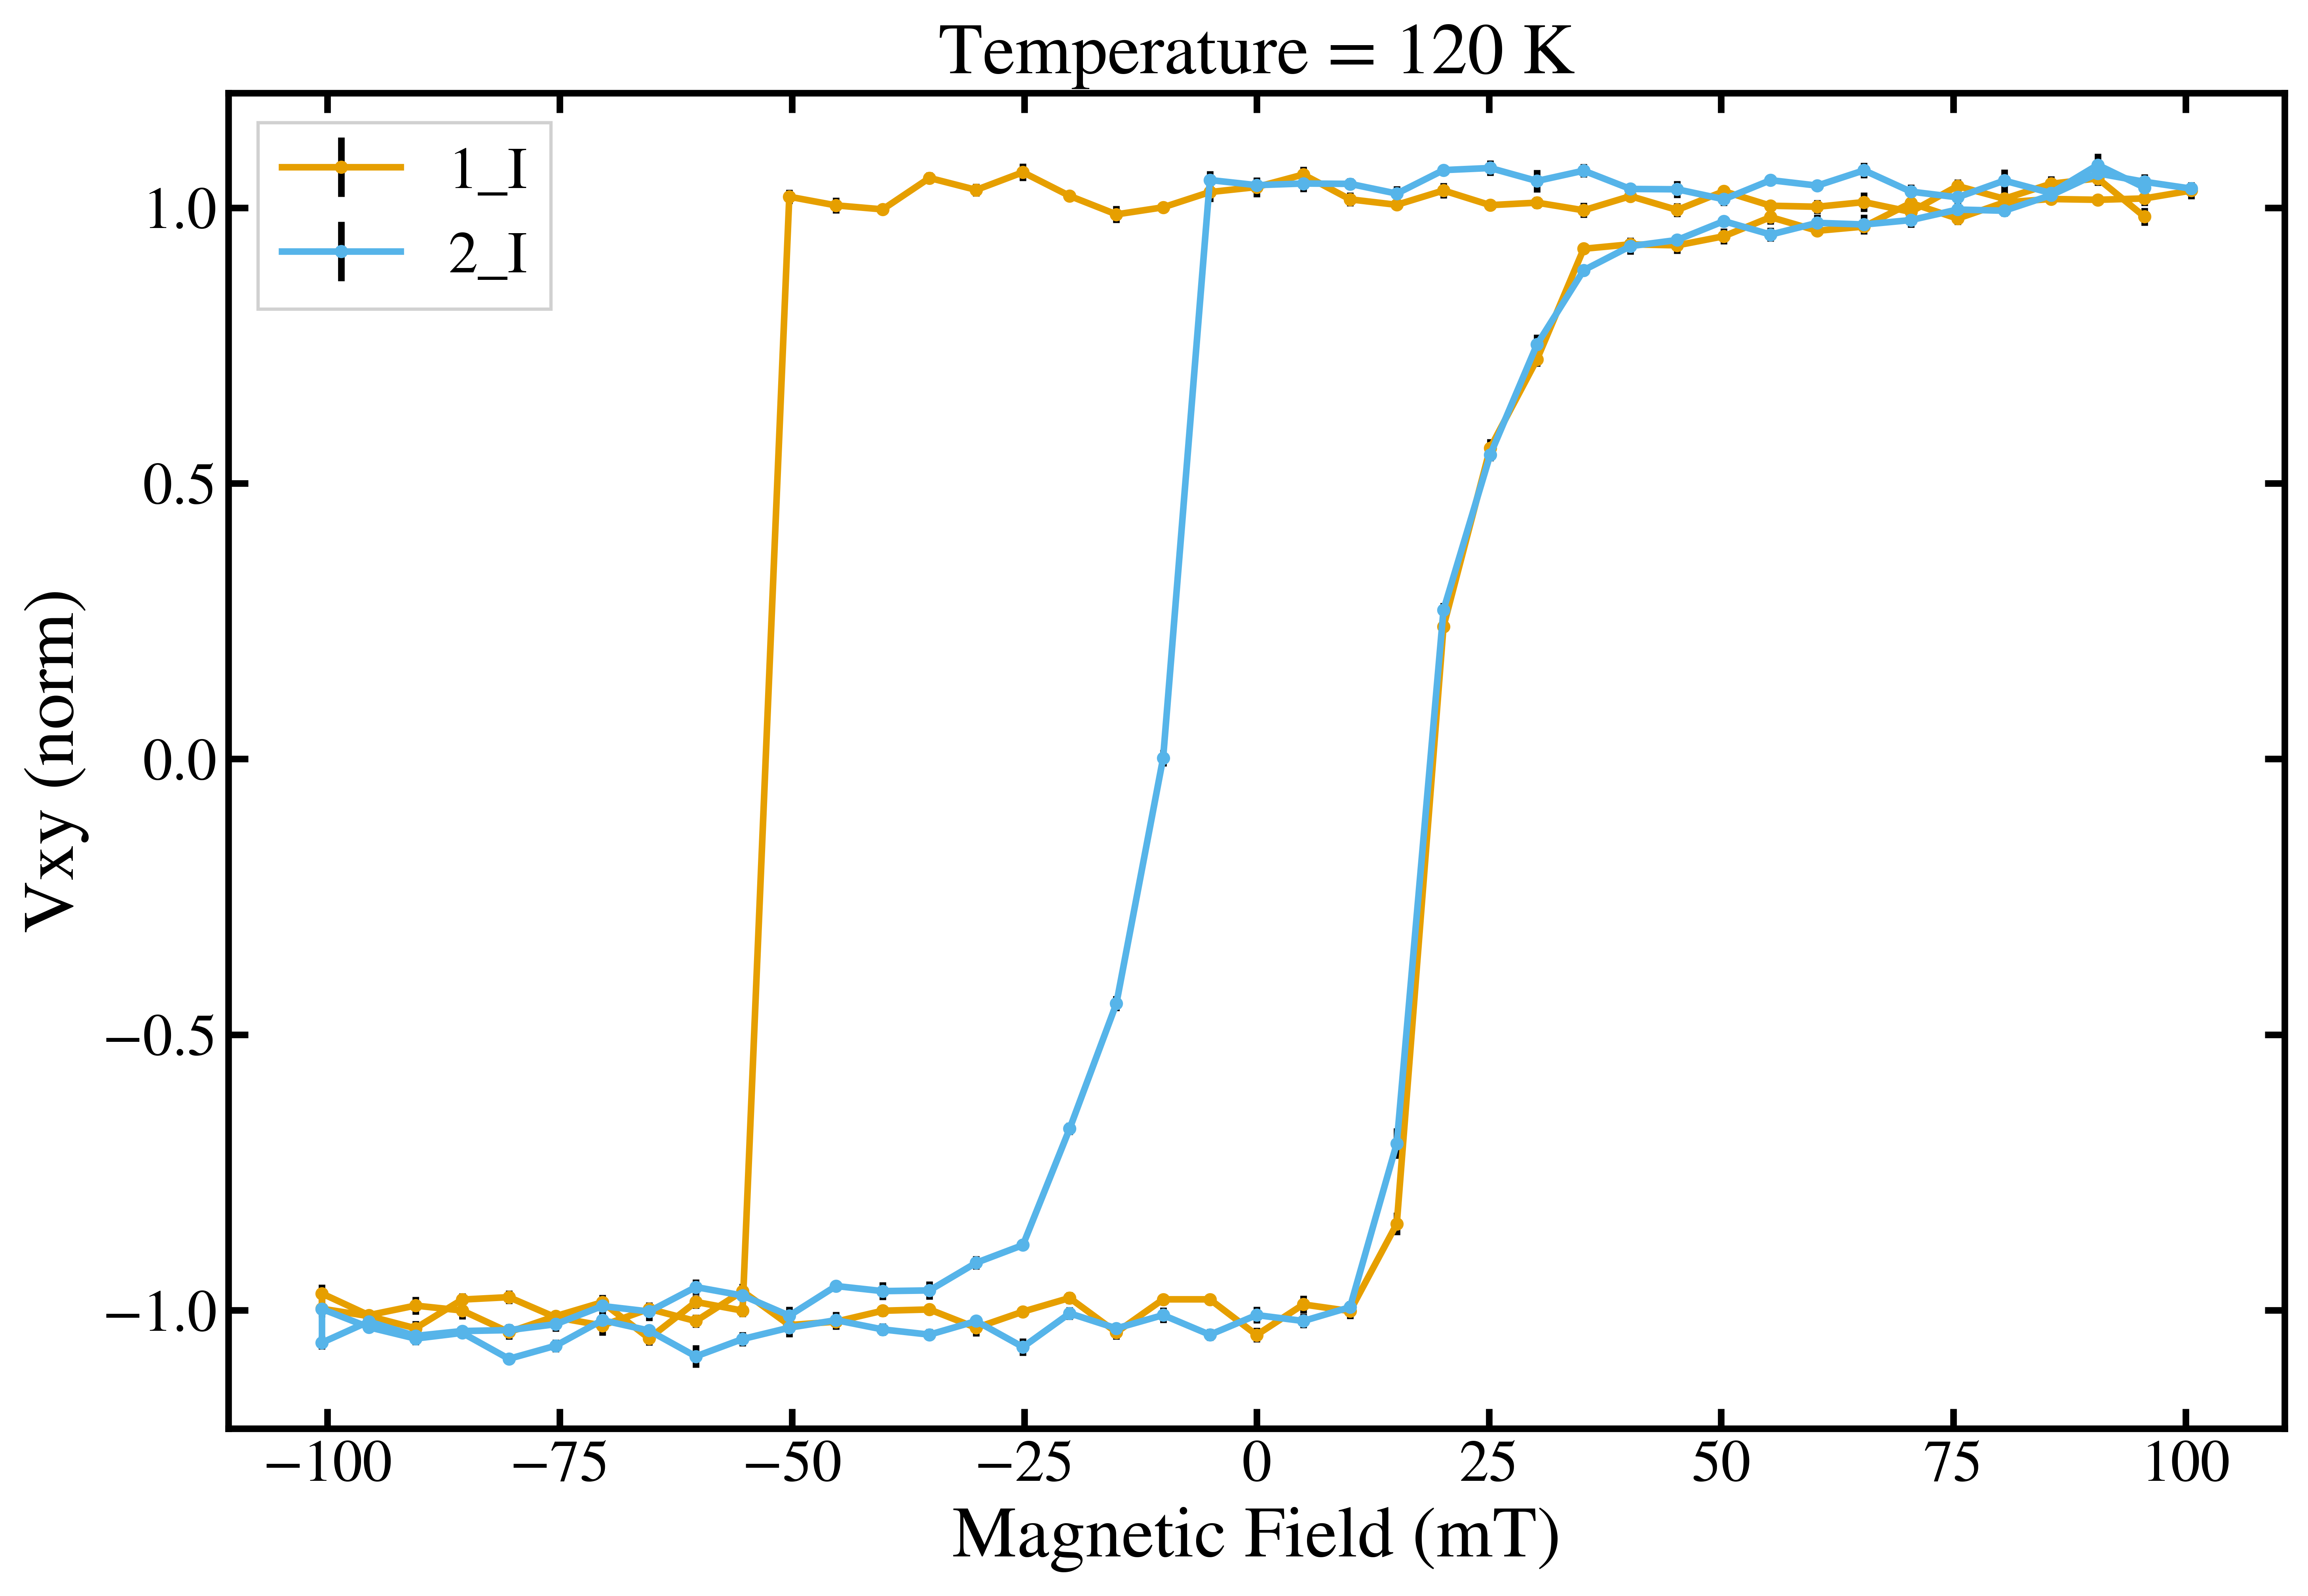

In [31]:
FOLDER_120K = TRAININGBASE / 'Training_effect_field_cooled' / 'Training_effect_120K'
res_120K = analyse_training_folder(FOLDER_120K)
if res_120K:
    summary_plots(res_120K, '120 K')